# MCSA Motor Fault Detection
### Ali Ashoor | General Assembly Data Science Bootcamp | Cohort DSB PT3 | Bahrain, August 2026

**Topic:** Machine learning fault classification for three-phase induction motors using Motor Current Signature Analysis

---
## 1. Introduction

### 1.1 Project Overview

Induction motors account for nearly 70% of industrial electricity consumption worldwide ([Eichhammer, 2012](https://www.researchgate.net/publication/265395773_Energy_efficiency_in_electric_motor_systems_Technology_saving_potentials_and_policy_options_for_developing_countries)), making their reliability critical to manufacturing, processing, and utilities sectors. When a motor fails unexpectedly, the cost of downtime frequently exceeds the cost of the motor itself, leading to significant production losses and maintenance expenses.

Among the most common failure modes, stator-related faults account for 36–38% of failures and rotor-related faults account for 10% ([Maraaba, 2018](https://www.mdpi.com/1996-1073/11/3/653)). The two fault types studied in this project — Broken Rotor Bar (BRB) and Stator Winding Fault (SWF) — together represent nearly half of all induction motor failures in industrial settings.

Early detection of these faults before they escalate to full motor failure is the goal of condition monitoring. Several approaches exist: vibration analysis is effective but requires dedicated accelerometers mounted on the motor casing, adding hardware cost and installation complexity. Thermal imaging can detect winding hotspots but requires line-of-sight access and is unsuitable for continuous online monitoring. Motor Current Signature Analysis (MCSA) avoids both limitations — it is a fully non-invasive technique that detects fault-specific frequency signatures directly from stator current measurements, using existing current sensors with no additional hardware.

The limitation of conventional MCSA systems, however, is that they rely on hand-crafted, threshold-based rules — for example, checking whether a sideband ratio at `f ± 2sf` exceeds a fixed threshold. These rules require domain expertise to configure, are sensitive to changes in operating speed and load, and do not generalise across different motor types without manual re-tuning.

**This project asks:** Can a machine learning classifier trained on engineered time-domain and FFT-based features from three-phase motor current signals match or outperform the existing rule-based MCSA fault detection system developed in a prior senior thesis (Bahrain Polytechnic, 2024) — and which feature extraction approach (time-domain, FFT, wavelet, or hybrid) provides the strongest classification performance?

**Target variable:** `condition` — a three-class label: `healthy`, `brb` (Broken Rotor Bar), `swf` (Stator Winding Fault).

**Success metrics:** Weighted F1-score ≥ 0.90 on a held-out test set; per-class precision and recall ≥ 0.85 for each fault type.

### 1.2 Research Question and Objectives

**Research question:** Can a machine learning classifier trained on engineered features from 
three-phase motor current signals match or outperform an existing rule-based MCSA fault 
detection system, and which feature extraction approach performs best?

**Objectives:**

1. Do raw signal amplitude values contain useful information for identifying fault conditions, 
   or is frequency-domain feature extraction required first?
2. Which signal statistics — such as RMS and kurtosis — show the clearest difference between 
   healthy, BRB, and SWF motors?
3. Are the five measurement replicates per phase consistent, or do they introduce unwanted 
   variability?
4. Does operating speed affect how a fault appears in the signal, and must this be accounted 
   for in the model?
5. Which feature extraction approach — time-domain, FFT, wavelet, or a combination — gives the 
   best classification performance?

### 1.3 Dataset Description

The master dataset was compiled from raw per-phase, per-measurement CSV files from the Bruinsma et al. (2024) experimental dataset (Motor 2 only). Each row represents one time-domain current sample at a specific operating point.

**Data Source:**[Motor Current and Vibration Monitoring Dataset for various Faults in an E-motor-driven Centrifugal Pump](https://doi.org/10.4121/2b61183e-c14f-4131-829b-cc4822c369d0)  

| Column | Type | Description |
|--------|------|-------------|
| `time` | float64 | Timestamp of the sample in seconds, relative to the start of each recording |
| `A_m1` | float64 | Phase A current amplitude (Amperes) — measurement replicate 1 |
| `A_m2` | float64 | Phase A current amplitude (Amperes) — measurement replicate 2 |
| `A_m3` | float64 | Phase A current amplitude (Amperes) — measurement replicate 3 |
| `A_m4` | float64 | Phase A current amplitude (Amperes) — measurement replicate 4 |
| `A_m5` | float64 | Phase A current amplitude (Amperes) — measurement replicate 5 |
| `B_m1` | float64 | Phase B current amplitude (Amperes) — measurement replicate 1 |
| `B_m2` | float64 | Phase B current amplitude (Amperes) — measurement replicate 2 |
| `B_m3` | float64 | Phase B current amplitude (Amperes) — measurement replicate 3 |
| `B_m4` | float64 | Phase B current amplitude (Amperes) — measurement replicate 4 |
| `B_m5` | float64 | Phase B current amplitude (Amperes) — measurement replicate 5 |
| `C_m1` | float64 | Phase C current amplitude (Amperes) — measurement replicate 1 |
| `C_m2` | float64 | Phase C current amplitude (Amperes) — measurement replicate 2 |
| `C_m3` | float64 | Phase C current amplitude (Amperes) — measurement replicate 3 |
| `C_m4` | float64 | Phase C current amplitude (Amperes) — measurement replicate 4 |
| `C_m5` | float64 | Phase C current amplitude (Amperes) — measurement replicate 5 |
| `speed` | int64 | Motor load speed as a percentage of rated speed: `50`, `75`, or `100` |
| `condition` | object | **Target variable.** Motor fault condition: `healthy`, `brb` (Broken Rotor Bar), `swf` (Stator Winding Fault) |

**Notes:**
- Signal columns follow the naming pattern `{phase}_{measurement}` where phase {A, B, C} and measurement {m1, m2, m3, m4, m5}.
- Each measurement replicate is an independent experimental run under the same condition and speed — not a sensor channel.
- The dataset covers 9 operating groups (3 conditions × 3 speeds), each contributing 300,000 rows.

---
## 2. Imports & Constants

In [61]:
# ─────────────────────────────────────────────
# 0. Imports & Constants
# ─────────────────────────────────────────────

# ── Core libraries for data handling and numerical computation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Signal processing — FFT and general signal utilities
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis

# ── Wavelet transforms for the WT pipeline
import pywt
from scipy.signal import iirnotch, filtfilt
from joblib import Parallel, delayed

# ── Preprocessing — encoding labels and scaling features
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Classifiers — Dummy baseline, Random Forest, and SVM
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ── Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# ── Evaluation metrics
from sklearn.metrics import (
    f1_score,               # Primary metric — weighted F1
    precision_score,        # Per-class precision
    recall_score,           # Per-class recall
    confusion_matrix,       # Fault confusion visualization
    roc_auc_score,          # Secondary metric — one-vs-rest AUC
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)

# ── Plot defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4)})

# ── Dataset path
DATA_PATH       = 'data/mcsa_master_dataset.parquet'

# ── Signal recording parameters
SAMPLE_RATE     = 20000        # Sampling rate in Hz (20 kHz per dataset spec)
WINDOW_SIZE     = 1024         # Samples per window
STEP_SIZE       = 512          # Step size — 50% overlap between adjacent windows

# ── Supply frequency per speed setting (VFD-controlled, 4-pole motor)
# Derived from rotor RPM and consistent slip of ~1.33%
SUPPLY_FREQ = {
    50:  25.0,   # Hz
    75:  37.5,   # Hz
    100: 50.0    # Hz
}

# ── Motor slip (consistent across all speed settings)
SLIP = 0.0133

# ── Signal columns — 15 total: 3 phases × 5 measurement replicates
SIGNAL_COLS     = [f'{ph}_m{i}' for ph in ['A', 'B', 'C'] for i in range(1, 6)]

# ── Ordered labels for consistent indexing throughout the notebook
CONDITION_ORDER = ['healthy', 'brb', 'swf']
SPEED_ORDER     = [50, 75, 100]

# ── Modeling parameters
RANDOM_STATE    = 42            # Seed for reproducibility across all models
TRAIN_RATIO     = 0.80          # 80% train, 20% test — applied before windowing
SAMPLE_N        = 50000         # Rows used for heavy distribution/correlation plots

# ── Cross-validation strategy — shared across all tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Plot colors per fault condition
PALETTE         = {'healthy': '#2ecc71', 'brb': '#1a3a6b', 'swf': '#e74c3c'}

In [64]:
df.head()

,time,A_m1,B_m1,C_m1,A_m2,B_m2,C_m2,A_m3,B_m3,C_m3,A_m4,B_m4,C_m4,A_m5,B_m5,C_m5,speed,condition
0,0.00005,3.008112,22.242159,-24.287834,25.737957,-9.874649,-15.778249,18.146170,-24.400459,5.771639,-22.832848,-7.520176,30.482080,-28.979891,24.467091,5.640152,100,healthy
1,0.00010,2.451916,22.851290,-24.350483,25.655579,-9.530465,-16.185856,18.521677,-24.407204,5.298334,-22.014360,-8.193046,30.141418,-29.249149,24.527622,5.827123,100,healthy
2,0.00015,1.823028,23.583891,-24.382334,25.782387,-9.209298,-16.485453,19.160528,-23.988369,4.356100,-22.580967,-7.967415,30.581587,-29.046022,23.797901,6.286219,100,healthy
3,0.00020,1.305648,24.197058,-24.521708,25.505650,-8.242023,-17.209127,19.483103,-24.220560,4.210232,-21.292551,-8.737899,30.063391,-29.277792,23.951210,6.467302,100,healthy
4,0.00025,0.647593,24.997971,-24.620201,25.733488,-8.325099,-17.378656,20.150885,-23.920687,3.236333,-21.665260,-8.753317,30.315128,-29.282063,23.489681,6.787510,100,healthy


---
## 3. Load Dataset

In [62]:
df = pd.read_parquet('data/mcsa_master_dataset.parquet')
print(f'Shape: {df.shape}')
print()
df.head()
print()
df.info()
print()
df[SIGNAL_COLS].describe().T

Shape: (2700000, 18)


<class 'pandas.DataFrame'>
RangeIndex: 2700000 entries, 0 to 2699999
Data columns (total 18 columns):
 #   Column     Dtype  
---  ------     -----  
 0   time       float32
 1   A_m1       float32
 2   B_m1       float32
 3   C_m1       float32
 4   A_m2       float32
 5   B_m2       float32
 6   C_m2       float32
 7   A_m3       float32
 8   B_m3       float32
 9   C_m3       float32
 10  A_m4       float32
 11  B_m4       float32
 12  C_m4       float32
 13  A_m5       float32
 14  B_m5       float32
 15  C_m5       float32
 16  speed      int64  
 17  condition  str    
dtypes: float32(16), int64(1), str(1)
memory usage: 217.2 MB



,count,mean,std,min,25%,50%,75%,max
A_m1,2700000.0,0.188575,15.018888,-33.032070,-11.468369,0.099125,11.842178,33.195248
A_m2,2700000.0,0.186167,15.057586,-32.881691,-11.445313,0.096950,11.822865,33.364395
A_m3,2700000.0,0.186326,15.070592,-33.063393,-11.493919,0.092014,11.863933,33.852318
A_m4,2700000.0,0.187570,15.036671,-33.282280,-11.481879,0.098336,11.855481,33.623402
A_m5,2700000.0,0.184384,15.072539,-33.502102,-11.491278,0.092434,11.862063,33.776737
B_m1,2700000.0,0.085861,15.036199,-33.019436,-11.526440,-0.014407,11.708542,33.253822
B_m2,2700000.0,0.086579,15.075357,-33.270412,-11.526443,-0.012474,11.710704,33.321529
B_m3,2700000.0,0.090020,15.123586,-33.463482,-11.528152,-0.005902,11.713754,33.596825
B_m4,2700000.0,0.085870,15.139821,-33.246696,-11.549167,-0.007966,11.731985,33.782585
B_m5,2700000.0,0.089641,15.095247,-33.393711,-11.534698,-0.005784,11.720565,33.304287


---
## 4. Exploratory Data Analysis (EDA)

EDA is organised into two layers:
- **EDA for Insights** — understanding signal behaviour, condition separation, and speed effects
- **EDA for Modeling** — quantifying discriminative power of raw features and justifying the feature extraction strategy

---
### EDA Sample

Heavy EDA operations — distributions, correlations, and statistical comparisons — are computed on a **stratified sample of ~50,000 rows**, drawn evenly from all 9 condition × speed groups (~5,555 rows per group). This keeps every group equally represented, so no single condition or speed dominates the sample, while keeping computation fast on a 2.7M-row dataset.

In [3]:
samples = []
for (cond, spd), grp in df.groupby(['condition', 'speed']):
    samples.append(grp.sample(n=SAMPLE_N // 9, random_state=RANDOM_STATE))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f'Sample shape: {df_sample.shape}')
print(df_sample.groupby(['condition', 'speed']).size().unstack())

Sample shape: (49995, 18)
speed       50    75    100
condition                  
brb        5555  5555  5555
healthy    5555  5555  5555
swf        5555  5555  5555


---
### 4.1 Data Overview

In [4]:
print('--- Condition counts ---')
print(df['condition'].value_counts())
print()
print('--- Speed counts ---')
print(df['speed'].value_counts().sort_index())
print()
print('--- Group counts (condition × speed) ---')
print(df.groupby(['condition','speed']).size().unstack())

--- Condition counts ---
condition
healthy    900000
brb        900000
swf        900000
Name: count, dtype: int64

--- Speed counts ---
speed
50     900000
75     900000
100    900000
Name: count, dtype: int64

--- Group counts (condition × speed) ---
speed         50      75      100
condition                        
brb        300000  300000  300000
healthy    300000  300000  300000
swf        300000  300000  300000


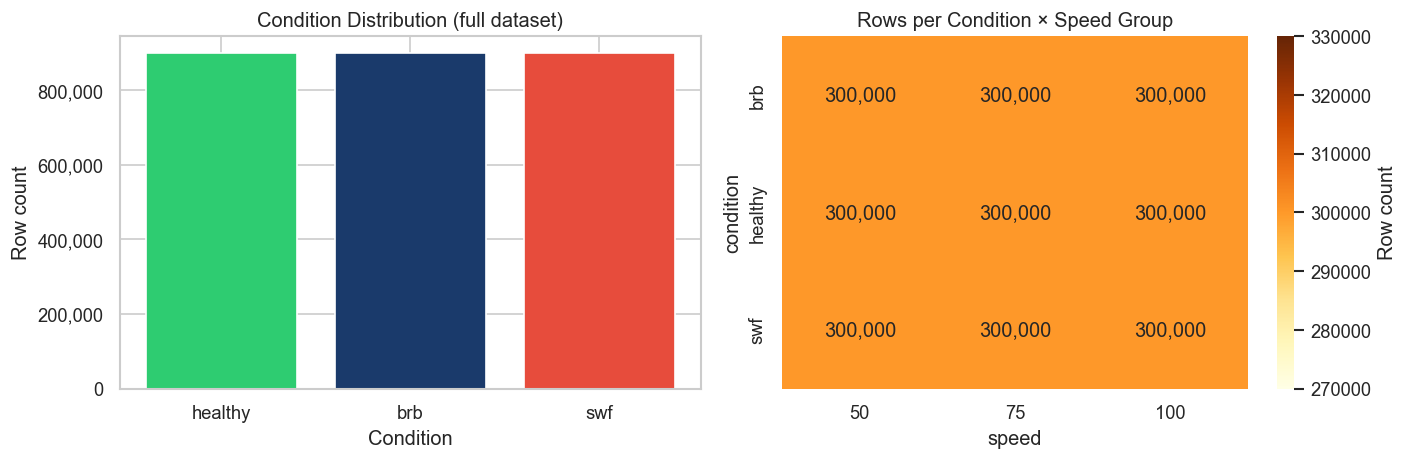

In [5]:
# Target class distribution — bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Condition counts
condition_counts = df['condition'].value_counts().reindex(CONDITION_ORDER)
axes[0].bar(condition_counts.index, condition_counts.values,
            color=[PALETTE[c] for c in condition_counts.index], edgecolor='white')
axes[0].set_title('Condition Distribution (full dataset)')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Row count')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Condition × speed heatmap
group_matrix = df.groupby(['condition','speed']).size().unstack()
sns.heatmap(group_matrix, annot=True, fmt=',', cmap='YlOrBr', ax=axes[1],
            cbar_kws={'label': 'Row count'})
axes[1].set_title('Rows per Condition × Speed Group')

plt.tight_layout()
plt.show()

#### Target Distribution Summary

Both visualisations confirm the perfectly balanced design of the dataset. The bar chart shows all three conditions — healthy, brb, swf — at exactly 900,000 rows each, with no visible skew toward any single class. The heatmap breaks this down further across the 9 condition × speed combinations, with every cell showing exactly 300,000 rows.

This balance means no class-weighting, oversampling, or undersampling will be needed when models are trained later — the dataset is already structured to give equal representation to every fault condition at every operating speed.

---
### 4.2 Data Cleaning

This is a raw experimental signal dataset — standard tabular cleaning (imputation, deduplication, type coercion) does not apply. Cleaning here means **signal integrity validation**: confirming the dataset is structurally correct and free of corrupted recordings before feature extraction.

The four checks performed are:
1. **Null check** — confirm zero missing values across all columns
2. **Group row count verification** — confirm all 9 condition × speed groups contain exactly 300,000 rows
3. **Amplitude range check** — flag any signal column with abnormal min/max values

In [6]:
print('1. Null check')
print()
# 1. Null check
null_counts = df.isnull().sum()
print('Null values per column:')
print(null_counts[null_counts > 0] if null_counts.any() else 'No null values found. ✓')

print()
print("-" * 60)

print('2. Group row count verification')
print()
# 2. Group row count verification
group_counts = df.groupby(['condition', 'speed']).size().unstack()
violations = (group_counts != 300_000).any().any()

print(group_counts)
print()
print('All 9 groups have exactly 300,000 rows. ✓' if not violations else 'Violations found!')

print()
print("-" * 60)
print()
print('3. Amplitude range check')
# 3. Amplitude range check — compare per-column min/max against expected physical range
# Induction motor phase current is typically within ±10A at rated load for this motor size
EXPECTED_AMP_MIN = -35
EXPECTED_AMP_MAX =  35

amp_signal = df[SIGNAL_COLS].agg(['min','max'])
out_of_range = amp_signal.loc[:, (amp_signal.loc['min'] < EXPECTED_AMP_MIN) |
                                  (amp_signal.loc['max'] > EXPECTED_AMP_MAX)]
print('Signal columns outside expected amplitude range (±34A):')
print(out_of_range if not out_of_range.empty else 'All columns within expected range.')
print()
print('Actual amplitude range per column:')
print(amp_signal.T)

1. Null check

Null values per column:
No null values found. ✓

------------------------------------------------------------
2. Group row count verification

speed         50      75      100
condition                        
brb        300000  300000  300000
healthy    300000  300000  300000
swf        300000  300000  300000

All 9 groups have exactly 300,000 rows. ✓

------------------------------------------------------------

3. Amplitude range check
Signal columns outside expected amplitude range (±34A):
All columns within expected range.

Actual amplitude range per column:
            min        max
A_m1 -33.032070  33.195248
A_m2 -32.881691  33.364395
A_m3 -33.063393  33.852318
A_m4 -33.282280  33.623402
A_m5 -33.502102  33.776737
B_m1 -33.019436  33.253822
B_m2 -33.270412  33.321529
B_m3 -33.463482  33.596825
B_m4 -33.246696  33.782585
B_m5 -33.393711  33.304287
C_m1 -32.656967  32.797409
C_m2 -33.406631  33.199757
C_m3 -33.051918  32.994122
C_m4 -33.040520  32.944237
C_m5 -33.

#### Data Inspection Summary

The master dataset contains 2,700,000 rows and 18 columns, stored efficiently as `float32` for all signal columns and `int64`/`str` for `speed` and `condition`. All 15 signal columns show a consistent statistical profile: mean current near zero (expected for an AC signal), standard deviation around 15A, and amplitude ranging between roughly **-33A and +34A** across all phases and measurement replicates — confirming uniform sensor calibration throughout the experiment. The dataset is perfectly balanced across both target classes and operating conditions: 900,000 rows per condition (healthy, brb, swf) and 900,000 rows per speed (50%, 75%, 100%), with all 9 condition × speed groups containing exactly 300,000 rows each.

Because this is raw experimental signal data rather than standard tabular data, cleaning focused on **signal integrity validation** instead of conventional steps like imputation or deduplication. Four checks were performed:

| Check | What it catches | Result |
|-------|------------------|--------|
| **Null check** | Missing or unrecorded values | 0 missing values across all 18 columns  |
| **Group row count verification** | Recordings duplicated or missing when the dataset was built | All 9 condition × speed groups contain exactly 300,000 rows  |
| **Amplitude range check** | Sensor readings clipped or distorted beyond the normal range | All signal values fall within the expected ±34A physical range  |

**Conclusion:** The dataset passed all three integrity checks with no anomalies. It required no corrective cleaning and is confirmed reliable for EDA and downstream feature extraction.

---
### 4.3 Signal Waveforms

Visualise 1,024 consecutive samples (one window) of Phase A, measurement m1, at 100% speed for each condition. This gives a baseline visual impression of whether fault conditions alter the raw time-domain waveform shape.

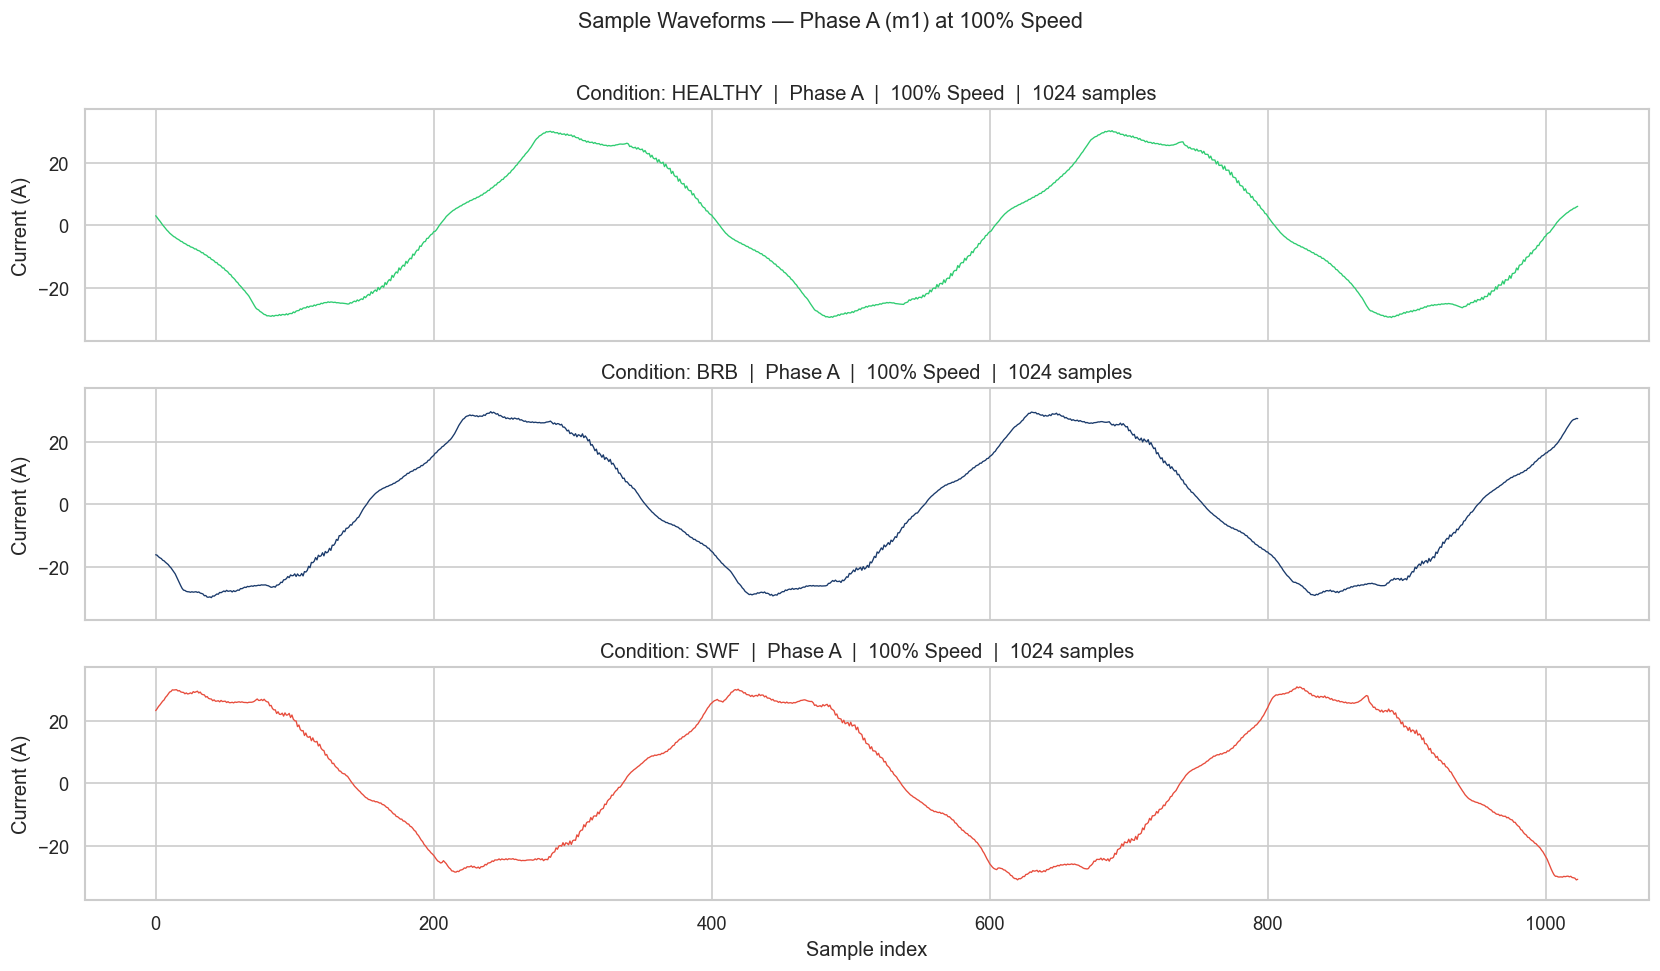

In [7]:
# Waveform visualisation — Phase A, m1, 100% speed, one window per condition
actual_max = df[SIGNAL_COLS].abs().max().max()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, cond in zip(axes, CONDITION_ORDER):
    window = (
        df[(df['condition'] == cond) & (df['speed'] == 100)]
        ['A_m1']
        .iloc[:WINDOW_SIZE]
        .values
    )
    ax.plot(window, color=PALETTE[cond], linewidth=0.8)
    ax.set_title(f'Condition: {cond.upper()}  |  Phase A  |  100% Speed  |  {WINDOW_SIZE} samples')
    ax.set_ylabel('Current (A)')
    ax.set_ylim(-actual_max * 1.1, actual_max * 1.1)

axes[-1].set_xlabel('Sample index')
plt.suptitle('Sample Waveforms — Phase A (m1) at 100% Speed', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Sample Waveforms Summary

All three conditions show the same fundamental sine wave shape, amplitude range (roughly ±34A), and cycle period — visually, healthy, BRB, and SWF current waveforms are nearly indistinguishable to the naked eye. None of the conditions shows an obvious distortion, spike, or amplitude shift that a simple visual threshold rule could catch.

This is the expected and important result. If fault conditions were visible directly in the time-domain waveform, no machine learning or signature analysis would be necessary — a basic visual or threshold check would suffice. The fact that all three conditions look alike at this scale supports the project's central hypothesis: fault signatures are subtle, frequency-domain phenomena (sidebands and harmonics) that are not visible in raw time-domain inspection, reinforcing the need for FFT-based feature extraction before classification.

---
### 4.4 Amplitude Distribution

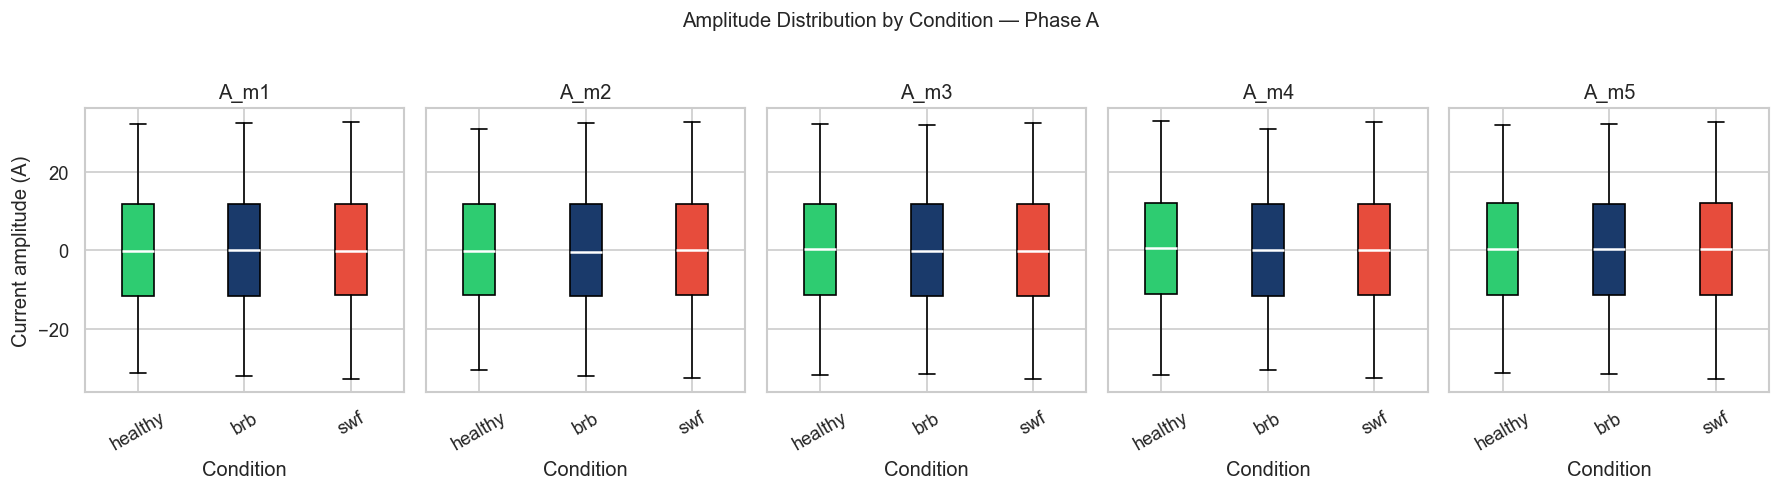

In [8]:
# Box plots of Phase A columns by condition (representative phase)
phase_a_cols = [c for c in SIGNAL_COLS if c.startswith('A_')]

fig, axes = plt.subplots(1, len(phase_a_cols), figsize=(15, 4), sharey=True)

for ax, col in zip(axes, phase_a_cols):
    data_by_cond = [df_sample[df_sample['condition'] == c][col].values
                    for c in CONDITION_ORDER]
    bp = ax.boxplot(data_by_cond, tick_labels=CONDITION_ORDER, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 1.5})
    for patch, cond in zip(bp['boxes'], CONDITION_ORDER):
        patch.set_facecolor(PALETTE[cond])
    ax.set_title(col)
    ax.set_xlabel('Condition')
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Current amplitude (A)')
plt.suptitle('Amplitude Distribution by Condition — Phase A', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### Amplitude Distributions Summary

Across all five measurement replicates (A_m1–A_m5), the box plots show essentially identical distributions for healthy, BRB, and SWF conditions: same median (~0A), same interquartile range (±12A), and same whisker extent (±34A). No condition shows a visibly wider spread, shifted median, or different shape than the others.

This confirms, at the distribution level, what the waveform plots already suggested: raw amplitude statistics do not separate fault conditions. Combined with the consistent shape across all five replicates, this also reinforces that m1–m5 behave as reliable, repeatable experimental runs rather than introducing extra variability. The result strengthens the case that any useful classification signal must come from feature extraction beyond simple amplitude distribution .

---
### 4.5 RMS & Kurtosis Analysis

RMS and kurtosis are the two most diagnostically relevant time-domain statistics for MCSA fault detection. RMS captures signal energy; kurtosis is sensitive to impulsive fault events.

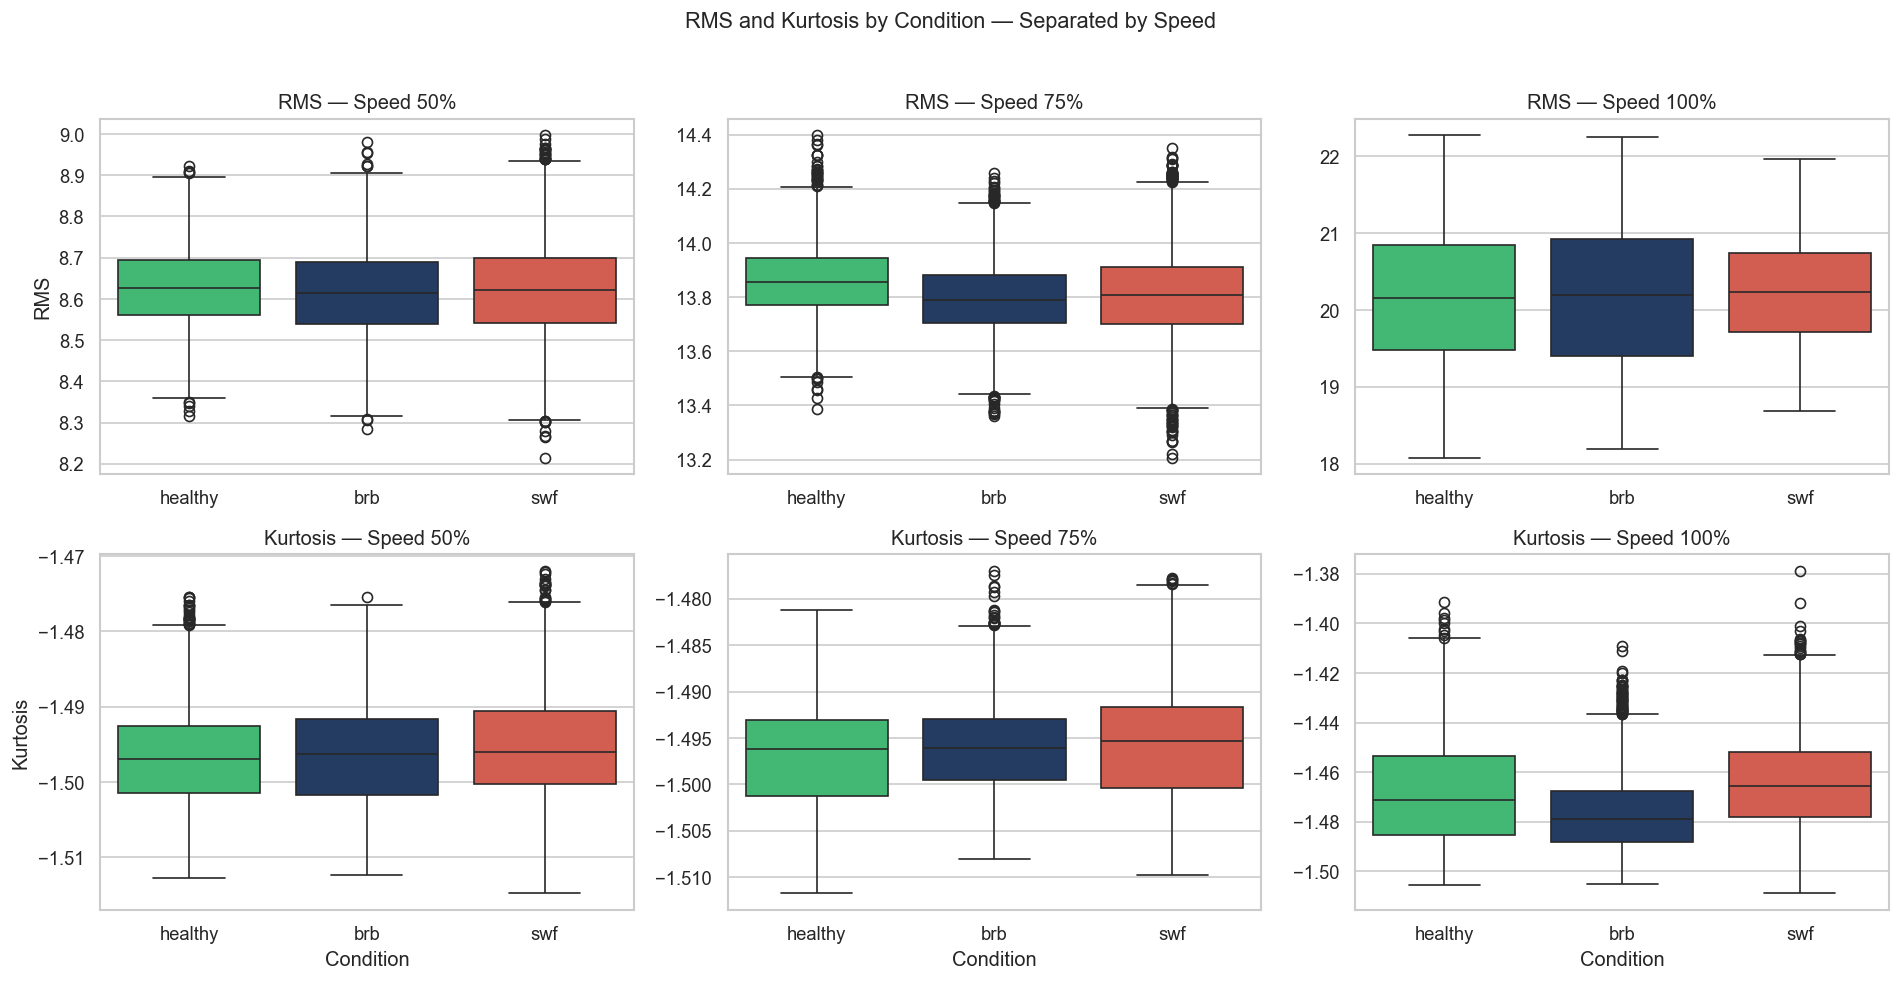

In [9]:
# RMS and Kurtosis by Condition, split by Speed (separate y-scale per speed)
df_sample['rms']      = np.sqrt((df_sample[SIGNAL_COLS] ** 2).mean(axis=1))
df_sample['kurtosis'] = df_sample[SIGNAL_COLS].apply(kurtosis, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col_idx, spd in enumerate(SPEED_ORDER):
    data = df_sample[df_sample['speed'] == spd]

    # RMS (top row)
    ax_rms = axes[0, col_idx]
    sns.boxplot(data=data, x='condition', y='rms', order=CONDITION_ORDER,
            hue='condition', palette=PALETTE, legend=False, ax=ax_rms)
    ax_rms.set_title(f'RMS — Speed {spd}%')
    ax_rms.set_xlabel('')
    ax_rms.set_ylabel('RMS' if col_idx == 0 else '')

    # Kurtosis (bottom row)
    ax_kurt = axes[1, col_idx]
    sns.boxplot(data=data, x='condition', y='kurtosis', order=CONDITION_ORDER,
            hue='condition', palette=PALETTE, legend=False, ax=ax_kurt)
    ax_kurt.set_title(f'Kurtosis — Speed {spd}%')
    ax_kurt.set_xlabel('Condition')
    ax_kurt.set_ylabel('Kurtosis' if col_idx == 0 else '')

plt.suptitle('RMS and Kurtosis by Condition — Separated by Speed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### RMS and Kurtosis Summary

We computed RMS and kurtosis per row and compared the three conditions.

RMS shows almost no separation between healthy, BRB, and SWF at any speed — the boxes overlap nearly completely. Kurtosis is mostly the same story, except at 100% speed, where BRB sits slightly lower than healthy and SWF. The difference is real but small, and the boxes still overlap significantly.

**Conclusion:** RMS does not help distinguish fault conditions. Kurtosis carries a weak signal only at higher speed, but neither metric is strong enough to classify faults on its own. This supports the case for frequency-domain feature extraction in the next phase.

---
### 4.6 Inter-Measurement Consistency

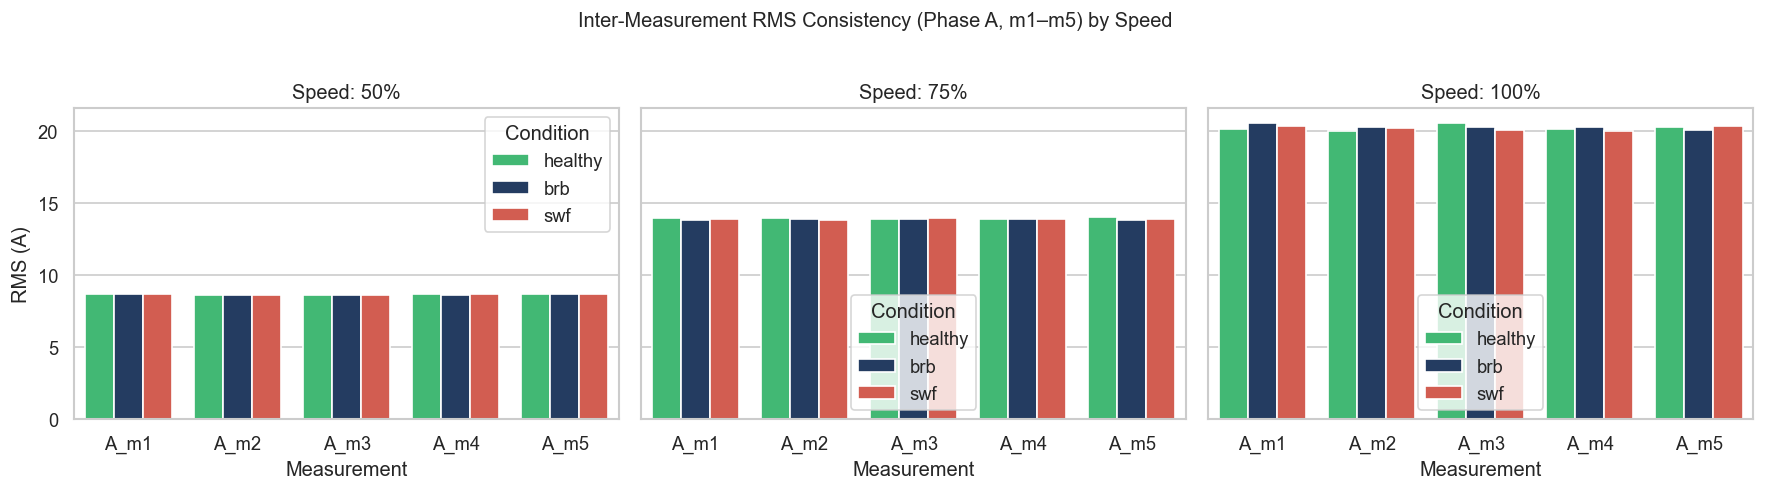

speed                     50       75         100
condition measurement                            
brb       A_m1         8.6666  13.8280  20.571301
          A_m2         8.6301  13.9032  20.264000
          A_m3         8.6120  13.9138  20.295300
          A_m4         8.6485  13.9189  20.238100
          A_m5         8.6806  13.7907  20.062300
healthy   A_m1         8.6810  13.9501  20.149900
          A_m2         8.6388  13.9824  19.984900
          A_m3         8.6202  13.8899  20.536400
          A_m4         8.6602  13.9209  20.142300
          A_m5         8.6763  13.9979  20.261700
swf       A_m1         8.6694  13.8564  20.335699
          A_m2         8.6373  13.8388  20.222200
          A_m3         8.6337  13.9586  20.034100
          A_m4         8.6523  13.9023  19.996201
          A_m5         8.6779  13.8716  20.319300


In [10]:
# Inter-measurement consistency — compare RMS of m1–m5 per condition × speed
phase_a_cols = [f'A_m{i}' for i in range(1, 6)]

rms_rows = []
for (cond, spd), grp in df_sample.groupby(['condition', 'speed']):
    for col in phase_a_cols:
        rms_val = np.sqrt((grp[col] ** 2).mean())
        rms_rows.append({'condition': cond, 'speed': spd, 'measurement': col, 'rms': rms_val})

rms_df = pd.DataFrame(rms_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, spd in zip(axes, SPEED_ORDER):
    data = rms_df[rms_df['speed'] == spd]
    sns.barplot(data=data, x='measurement', y='rms', hue='condition',
                hue_order=CONDITION_ORDER, palette=PALETTE, ax=ax)
    ax.set_title(f'Speed: {spd}%')
    ax.set_xlabel('Measurement')
    ax.set_ylabel('RMS (A)' if spd == 50 else '')
    ax.legend(title='Condition')

plt.suptitle('Inter-Measurement RMS Consistency (Phase A, m1–m5) by Speed', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(rms_df.pivot_table(index=['condition', 'measurement'], columns='speed', values='rms').round(4))

#### Inter-Measurement Consistency Summary

We checked whether the five measurement replicates (m1–m5) behave consistently with each other, since each represents an independent experimental run rather than a separate sensor. RMS was computed per measurement, per condition, per speed, and plotted side by side to compare m1 through m5 within each group.

At every speed, the five bars for each condition sit at nearly the same height — the spread between m1 and m5 is under 0.07A for 50% speed, and proportionally just as tight at 75% and 100%. This holds true across all three conditions.

**Conclusion:** The five measurement replicates are highly consistent and reproducible. This confirms they can be treated as independent, reliable training samples rather than a source of noise, which is good news for the modeling phase — it effectively gives more usable data per condition without compromising data quality.

---
### 4.7 Signal Correlation Matrix

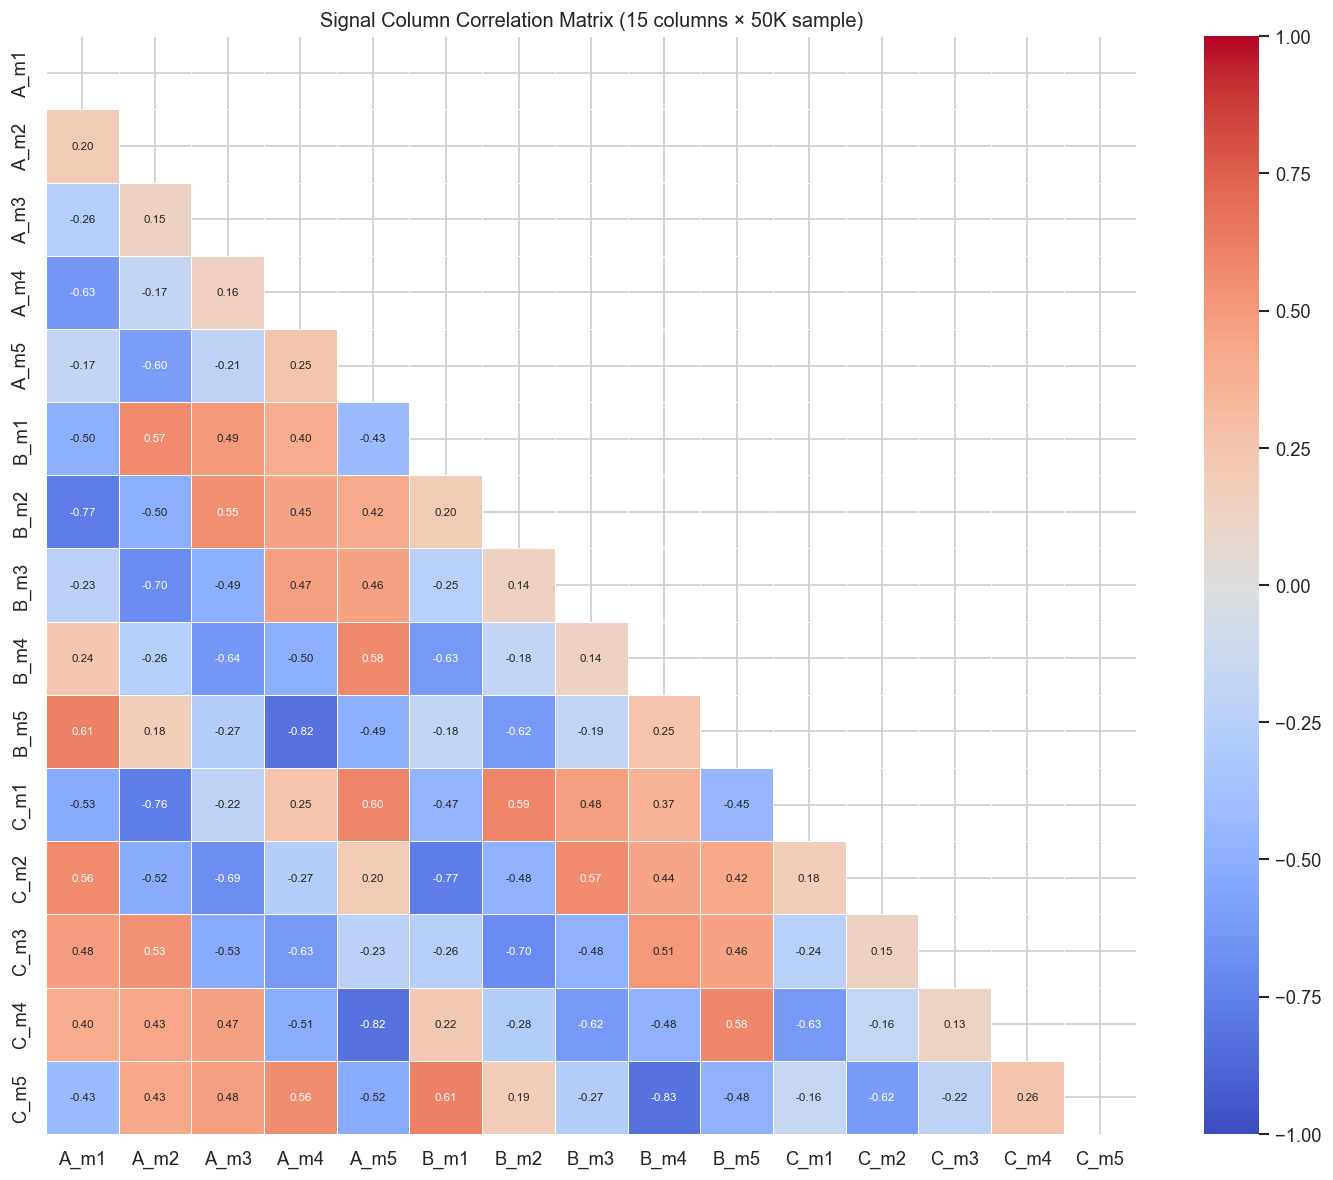

In [11]:
corr_matrix = df_sample[SIGNAL_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Signal Column Correlation Matrix (15 columns × 50K sample)')
plt.tight_layout()
plt.show()

#### Signal–Signal Correlation Summary

We computed Pearson correlation between all 15 signal columns to check for redundancy. The five replicates within the same phase (A_m1–A_m5) do not correlate strongly with each other, confirming they capture independent variation rather than duplicating the same signal. Cross-phase correlations are moderate (-0.82 to +0.61), which is expected given the 120° phase shift in a three-phase system. No column pair is near-perfectly correlated.

**Conclusion:** All 15 signal columns carry distinct information and can be retained for feature extraction without major redundancy concerns.

---
### 4.8 Condition Correlation

Encodes the condition label as an ordinal integer (healthy=0, brb=1, swf=2) and computes Pearson correlation against each signal column. This quantifies whether raw amplitude carries any linear discriminative information about fault condition.

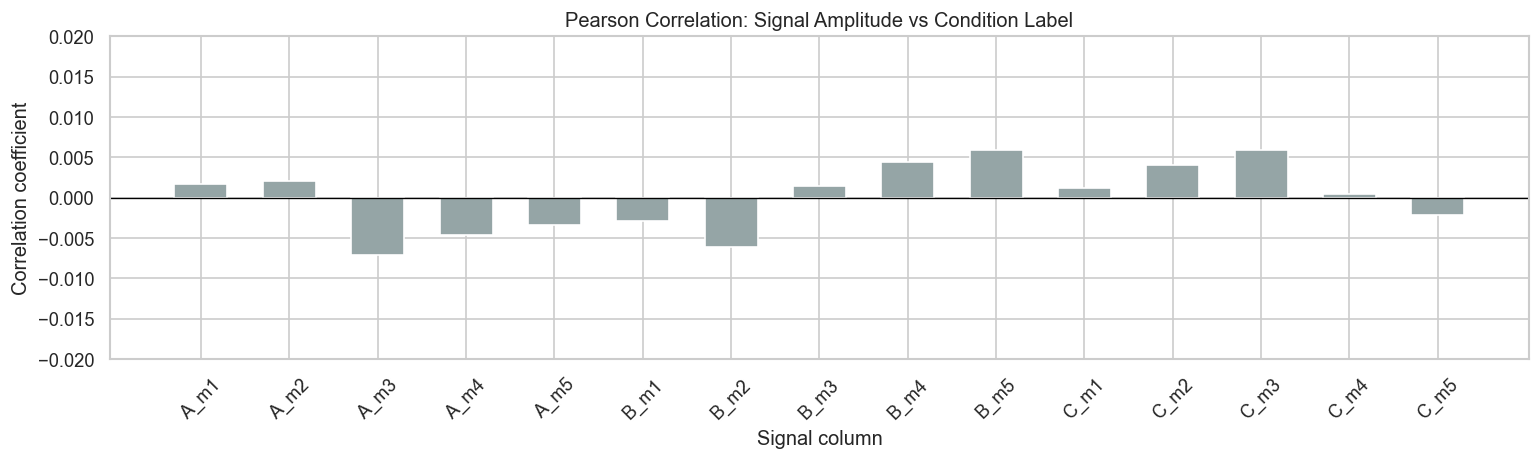

Max absolute correlation with condition: 0.0071


In [12]:
condition_map = {'healthy': 0, 'brb': 1, 'swf': 2}
df_sample['condition_encoded'] = df_sample['condition'].map(condition_map)

condition_corr = (df_sample[SIGNAL_COLS + ['condition_encoded']]
                  .corr()['condition_encoded']
                  .drop('condition_encoded'))

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#e74c3c' if abs(v) > 0.05 else '#95a5a6' for v in condition_corr.values]
ax.bar(condition_corr.index, condition_corr.values, color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation: Signal Amplitude vs Condition Label')
ax.set_xlabel('Signal column')
ax.set_ylabel('Correlation coefficient')
ax.set_ylim(-0.02, 0.02)  # zoomed in to actual data range
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Max absolute correlation with condition: {condition_corr.abs().max():.4f}')

#### Signal Amplitude vs Condition Correlation Summary

We encoded condition as an integer (healthy=0, brb=1, swf=2) and computed Pearson correlation against each signal column. Every column came back between -0.0071 and 0.0059 — effectively zero, with no column standing out.

**Conclusion:** Raw signal amplitude carries no usable information about fault condition. This confirms FFT-based feature extraction is required before any classifier can distinguish healthy, BRB, and SWF.

---
### 4.9 EDA Summary & Key Findings

#### EDA Insight — Frequency Domain Justification

> **Finding:** Maximum Pearson correlation between raw signal amplitude and the condition label is ≈ 0.007 — effectively zero across all 15 signal columns.
>
> **Interpretation:** Raw time-domain amplitude contains no linear discriminative information about motor fault condition. This is the expected result in MCSA: fault signatures (BRB sidebands at `f ± 2sf`, SWF harmonics at `3f`, `5f`) manifest almost exclusively in the **frequency domain**. This finding directly validates the need for FFT-based feature extraction prior to ML classification, and is consistent with results reported in the original senior thesis rule-based system.
>
> **Implication for modeling:** Any model trained directly on raw signal amplitude columns will perform at chance level. Feature extraction (FFT, wavelet, or time-domain statistics on windowed segments) is a prerequisite, not an option.

#### EDA Summary

| Finding | Implication |
|---------|-------------|
| Dataset is perfectly balanced (900K rows per condition) | No class-weighting or resampling required |
| All 9 condition × speed groups have exactly 300,000 rows | Clean experimental design; no leakage risk from group imbalance |
| Raw amplitude correlation with condition ≈ 0.007 (max) | Fault signatures are frequency-domain phenomena; FFT extraction is mandatory before ML |
| RMS shows no separation between conditions at any speed | RMS alone will not contribute meaningfully to a time-domain feature pipeline |
| Kurtosis shows a weak, speed-dependent separation (notably at 100% speed) | May offer minor discriminative value as a secondary time-domain feature, but not sufficient alone |
| m1–m5 inter-measurement RMS is highly consistent within each group | Measurement replicates are reliable; all five can be used as independent training samples |
| Speed strongly affects RMS magnitude across all conditions | Speed must be included as a feature or used for stratified modeling |
| All 15 signal columns are weakly inter-correlated, no major redundancy | All columns can be retained going into feature extraction |

---
## 5. Preprocessing

---
### 5.1 Overview

#### Step 1 — Group-Based Train/Test Split (Leakage Prevention)

The split occurs at the **measurement-replicate level**, before any windowing takes place. 
Each replicate (m1–m5) is one complete, independent experimental run. Splitting by row order 
within a recording would leave train and test sharing the same run's sensor state and 
background noise; holding out an entire replicate forces evaluation on a run the model has 
never seen.

**Split used:** replicates m1–m4 → train (12 signal columns per group), replicate m5 → test 
(3 signal columns per group). This gives a naturally balanced 12/3 = 80/20 split across all 
conditions and speeds, with no shared experimental run between the two sets.

#### Step 2 — Sliding Window Segmentation

Each signal column is segmented into overlapping 1,024-sample windows, stepping forward by 
512 samples (50% overlap).

<img src="img/sliding_window_overlap.png" width="700">

The overlap matters because fault events don't always align neatly with window boundaries:

<img src="img/why_overlap_matters.png" width="700">

A fault event near a window boundary still ends up fully inside at least one window, instead 
of being cut in half and weakened in both.

Because the split is applied by column before segmentation, overlapping windows never cross 
the train/test boundary. This produces **63,072 training windows and 15,768 test windows** 
(78,840 total), perfectly balanced across the three fault conditions.

#### Step 3 — Feature Extraction Pipelines

Four parallel feature pipelines are built and compared:

| Pipeline | Features per window | Count |
|----------|---------------------|-------|
| **TD** — Time-Domain | Mean, RMS, STD, peak, kurtosis, skewness, crest factor, ZCR, shape factor, waveform length | 10 |
| **FFT** — Frequency-Domain | BRB sideband amplitudes and noise-floor ratios at `f ± 2ksf` (k=1–4), BRB zone energy, and lower/upper RSH energy ratios for odd harmonics H1–H25 | 43 |
| **CWT** — Wavelet | Mean energy, entropy, peak energy, and energy variance for a speed-relative BRB zone and a fixed 900–1,300 Hz SWF zone | 8 |
| **HYB** — Hybrid | Concatenation of TD + FFT + CWT | 61 |

#### Step 4 — Encoding and Scaling

- `condition` label-encoded for classifier input (classes: brb, healthy, swf)
- StandardScaler applied per pipeline, **fit on the training set only** to avoid leaking 
  test-set statistics into the scaling

---
### 5.2 Group-Based Train/Test Split (by Measurement Replicate)

Split is performed at the recording level — per condition × speed group — before any windowing.
This prevents data leakage from overlapping windows straddling the train/test boundary.

In [13]:
# ─────────────────────────────────────────────
# 5.2 Group-Based Train/Test Split (by Measurement Replicate)
# ─────────────────────────────────────────────
# Split by whole measurement replicate — NOT by row order.
# Each replicate (m1–m5) is one complete, independent experimental run.
# Holding out an entire replicate (m5) forces the model to be tested on a
# completely unseen run, proving it learned fault physics rather than
# memorizing the background noise of a run it already partly trained on.
#
# Train replicates: m1, m2, m3, m4   →  12 columns per group (A/B/C × m1–m4)
# Test replicate:   m5               →   3 columns per group (A/B/C × m5)
# This gives a naturally balanced 12/3 = 80/20 split across all conditions/speeds.

TRAIN_REPLICATES = ['m1', 'm2', 'm3', 'm4']
TEST_REPLICATES  = ['m5']

# Signal columns routed to each split, based on their replicate suffix
TRAIN_COLS = [c for c in SIGNAL_COLS if c.split('_')[1] in TRAIN_REPLICATES]
TEST_COLS  = [c for c in SIGNAL_COLS if c.split('_')[1] in TEST_REPLICATES]

# The full recording stays whole — no row-level splitting.
# train_df / test_df keep all rows; the split is expressed through the columns.
train_df = df
test_df  = df

# Verify the column routing
print(f"Train columns ({len(TRAIN_COLS)}): {TRAIN_COLS}")
print(f"Test columns  ({len(TEST_COLS)}): {TEST_COLS}")
print(f"\nRows available per split: {len(df):,} (full recordings kept intact)")

Train columns (12): ['A_m1', 'A_m2', 'A_m3', 'A_m4', 'B_m1', 'B_m2', 'B_m3', 'B_m4', 'C_m1', 'C_m2', 'C_m3', 'C_m4']
Test columns  (3): ['A_m5', 'B_m5', 'C_m5']

Rows available per split: 2,700,000 (full recordings kept intact)


---
### 5.3 Sliding Window Segmentation

Window size: 1,024 samples. Overlap: 50% (step size: 512 samples).  
Applied independently to train and test sets, per recording group.

In [14]:
# ─────────────────────────────────────────────
# 5.3 Sliding Window Segmentation
# ─────────────────────────────────────────────
def extract_windows(df, window_size, step_size, columns):
    """
    Windows each signal column independently per condition × speed group.
    Only the columns passed in are windowed — this is how the group-based
    train/test split (by measurement replicate) is applied.
    Each column is treated as a separate recording.
    Returns a DataFrame — one row per window.
    """
    rows = []
    for condition in CONDITION_ORDER:
        for speed in SPEED_ORDER:
            # Extract the group
            group = df[(df['condition'] == condition) & (df['speed'] == speed)]
            # Window only the columns assigned to this split
            for col in columns:
                signal_values = group[col].values
                # Slide the window across the signal
                start = 0
                while start + window_size <= len(signal_values):
                    window = signal_values[start:start + window_size]
                    rows.append({
                        'window':    window,      # 1,024 raw samples
                        'condition': condition,   # Target label
                        'speed':     speed,       # Operating speed
                        'source':    col          # Source signal column (replicate)
                    })
                    start += step_size
    return pd.DataFrame(rows)

# Apply windowing — train uses m1–m4 columns, test uses m5 columns
# The split is by replicate, so train and test never share an experimental run
train_windows = extract_windows(df, WINDOW_SIZE, STEP_SIZE, TRAIN_COLS)
test_windows  = extract_windows(df, WINDOW_SIZE, STEP_SIZE, TEST_COLS)

# Verify
print(f"Train windows: {len(train_windows):,}")
print(f"Test windows:  {len(test_windows):,}")
print(f"Total:         {len(train_windows) + len(test_windows):,}")
print(f"\nTrain condition balance:\n{train_windows['condition'].value_counts()}")
print(f"\nTest condition balance:\n{test_windows['condition'].value_counts()}")

Train windows: 63,072
Test windows:  15,768
Total:         78,840

Train condition balance:
condition
healthy    21024
brb        21024
swf        21024
Name: count, dtype: int64

Test condition balance:
condition
healthy    5256
brb        5256
swf        5256
Name: count, dtype: int64


In [15]:
# Verify
print(f"Train windows: {len(train_windows):,}")  # Expected: ~63,072
print(f"Test windows:  {len(test_windows):,}")   # Expected: ~15,768
print(f"Total:         {len(train_windows) + len(test_windows):,}")  # Expected: ~78,840

Train windows: 63,072
Test windows:  15,768
Total:         78,840


In [16]:
# Preview the windowed tables
print(f"Train Shape: {train_windows.shape}")
display(train_windows.head())

print(f"Test Shape: {test_windows.shape}")
display(test_windows.head())

Train Shape: (63072, 4)


,window,condition,speed,source
0,"[-11.707786, -11.457837, -12.004451, -11.45121...",healthy,50,A_m1
1,"[9.930778, 10.081561, 10.095061, 9.690267, 10....",healthy,50,A_m1
2,"[-0.7362149, 0.09380141, -0.1530188, -0.232466...",healthy,50,A_m1
3,"[-8.767251, -9.486772, -9.074485, -9.344781, -...",healthy,50,A_m1
4,"[12.357494, 12.012745, 12.506281, 12.137345, 1...",healthy,50,A_m1


Test Shape: (15768, 4)


,window,condition,speed,source
0,"[12.197785, 11.69656, 12.050879, 12.068309, 11...",healthy,50,A_m5
1,"[-9.375487, -8.908413, -9.335987, -8.888407, -...",healthy,50,A_m5
2,"[-0.06969382, 0.14681445, -0.6464226, 0.123403...",healthy,50,A_m5
3,"[9.5748415, 9.770621, 10.074503, 9.643116, 10....",healthy,50,A_m5
4,"[-12.146401, -11.826062, -11.984957, -12.18958...",healthy,50,A_m5


---
## 6. Feature Extraction

Four pipelines are applied to each window: Time-Domain (TD), Frequency-Domain (FFT), Wavelet (WT), and Hybrid (HYB).

---
### 6.1 Time-Domain Pipeline (TD)
Features per phase: RMS, STD, peak, kurtosis, skewness, crest factor, ZCR, shape factor, WL→ 10 features total.

In [17]:
# ─────────────────────────────────────────────
# 6.1 Time-Domain Feature Extraction (TD)
# ─────────────────────────────────────────────

from scipy.stats import kurtosis, skew

def extract_td_features(window):
    """
    Extracts 10 statistical features from a 1,024-sample window.
    - Mean         : average signal level — detects DC offset
    - RMS          : overall signal energy
    - STD          : signal variability
    - Peak         : maximum absolute amplitude
    - Kurtosis     : impulsiveness — sensitive to BRB fault impacts
    - Skewness     : signal asymmetry
    - Crest Factor : peak-to-RMS ratio — detects sharp transients
    - ZCR          : zero crossing rate — estimates frequency content
    - Shape Factor : RMS to mean absolute value ratio — waveform shape
    - WL           : waveform length — overall signal complexity
    """
    rms          = np.sqrt(np.mean(window ** 2))
    mean         = np.mean(window)
    std          = np.std(window)
    peak         = np.max(np.abs(window))
    kurt         = kurtosis(window)
    skewness     = skew(window)
    crest_factor = peak / rms if rms != 0 else 0
    zcr          = np.sum(np.diff(np.sign(window)) != 0) / len(window)
    shape_factor = rms / np.mean(np.abs(window)) if np.mean(np.abs(window)) != 0 else 0
    wl           = np.sum(np.abs(np.diff(window)))

    return [mean, rms, std, peak, kurt, skewness, crest_factor, zcr, shape_factor, wl]

# Column names
TD_FEATURE_NAMES = [
    'mean', 'rms', 'std', 'peak',
    'kurtosis', 'skewness', 'crest_factor',
    'zcr', 'shape_factor', 'waveform_length'
]

# Apply to every window in train and test
td_train = pd.DataFrame(
    train_windows['window'].apply(extract_td_features).tolist(),
    columns=TD_FEATURE_NAMES
)
td_test = pd.DataFrame(
    test_windows['window'].apply(extract_td_features).tolist(),
    columns=TD_FEATURE_NAMES
)

# Attach labels
td_train[['condition', 'speed']] = train_windows[['condition', 'speed']].values
td_test[['condition', 'speed']]  = test_windows[['condition', 'speed']].values

# Verify
print(f"TD Train shape: {td_train.shape}")  # Expected: (63,072 × 12)
print(f"TD Test shape:  {td_test.shape}")   # Expected: (15,768 × 12)
td_train.head()

TD Train shape: (63072, 12)
TD Test shape:  (15768, 12)


,mean,rms,std,peak,kurtosis,skewness,crest_factor,zcr,shape_factor,waveform_length,condition,speed
0,-1.607638,8.805233,8.657230,12.814342,-1.354671,0.353021,1.455310,0.013672,1.110446,395.544067,healthy,50
1,0.187679,8.057682,8.055496,12.587673,-1.374583,-0.002830,1.562195,0.016602,1.133997,414.878723,healthy,50
2,1.878602,8.728839,8.524288,12.587673,-1.356303,-0.323295,1.442079,0.018555,1.115948,431.293152,healthy,50
3,-2.164728,9.126184,8.865731,12.724248,-1.405125,0.411672,1.394257,0.015625,1.090576,407.669189,healthy,50
4,1.398390,8.477040,8.360905,12.901532,-1.357209,-0.217545,1.521938,0.014648,1.130988,400.278931,healthy,50


In [18]:
# Encode condition as numeric for correlation
le = LabelEncoder()
td_train['condition_encoded'] = le.fit_transform(td_train['condition'])

# Correlation of each TD feature with the encoded condition label
td_corr = td_train[TD_FEATURE_NAMES + ['condition_encoded']]\
          .corr()['condition_encoded']\
          .drop('condition_encoded')\
          .sort_values(ascending=False)

print("TD Feature Correlation with Condition Label:")
print(td_corr.round(4))

TD Feature Correlation with Condition Label:
waveform_length    0.2343
crest_factor       0.0928
kurtosis           0.0212
zcr                0.0137
peak               0.0130
shape_factor       0.0026
rms                0.0015
std                0.0015
skewness           0.0000
mean              -0.0002
Name: condition_encoded, dtype: float64


#### Time-Domain (TD) summary

Extracts statistical features directly from the raw signal amplitude.
No frequency transformation is applied — features describe the shape and behavior of the signal.

| Feature | Description |
|---|---|
| Mean | Average signal level — detects DC offset |
| RMS | Overall signal energy |
| STD | Signal variability |
| Peak | Maximum absolute amplitude |
| Kurtosis | Impulsiveness — sensitive to BRB fault impacts |
| Skewness | Signal asymmetry |
| Crest Factor | Peak-to-RMS ratio — detects sharp transients |
| ZCR | Zero crossing rate — estimates frequency content |
| Shape Factor | RMS to mean absolute value ratio |
| Waveform Length | Overall signal complexity |

**Total: 10 features per window**

---
### 6.2 Frequency-Domain Pipeline (FFT)

Features per phase: sideband energy ratios at f ± 2sf, harmonic amplitudes at 3f, 5f, 7f.

In [19]:
# ─────────────────────────────────────────────
# 6.2 Frequency-Domain Feature Extraction (FFT)
# ─────────────────────────────────────────────

# Motor and signal constants
ROTOR_SLOTS   = 20
SLIP          = 0.0133
ODD_HARMONICS = list(range(1, 26, 2))  # H1, H3, H5, ... H25 (13 harmonics)
BRB_K_ORDERS  = [1, 2, 3, 4]          # k=1,2 early stage, k=3,4 advanced damage

def get_fft_amplitude(freqs, fft_mag, target_freq, bandwidth=1.0):
    """
    Returns the peak FFT amplitude within a bandwidth around the target frequency.
    Uses a frequency band to account for slip fluctuation and spectral leakage.
    """
    mask = (freqs >= target_freq - bandwidth) & (freqs <= target_freq + bandwidth)
    if np.any(mask):
        return np.max(fft_mag[mask])
    return 0.0

def get_band_energy(freqs, fft_mag, target_freq, bandwidth=1.0):
    """
    Returns total energy (sum of squared amplitudes) within a frequency band.
    More robust than peak amplitude — captures noise skirts around fault frequencies.
    """
    mask = (freqs >= target_freq - bandwidth) & (freqs <= target_freq + bandwidth)
    if np.any(mask):
        return np.sum(fft_mag[mask] ** 2)
    return 0.0

def extract_fft_features(window, speed):
    """
    Extracts 43 fault-specific frequency features from a 1,024-sample window.

    BRB features (17):
    - Peak amplitude and ratio at f ± 2ksf for k=1,2,3,4 (16 features)
    - Total band energy across the full BRB sideband zone normalized by fundamental (1 feature)

    SWF features (26):
    - Lower and upper RSH band energy ratio for all odd harmonics H1–H25

    Total: 43 features per window
    """
    fs       = SUPPLY_FREQ[speed]

    # Compute FFT
    FFT_NFFT = 16384  # Zero-pad to 16,384 points
    freqs    = fftfreq(FFT_NFFT, d=1/SAMPLE_RATE)
    fft_mag  = np.abs(fft(window, n=FFT_NFFT))

    # Keep positive frequencies only
    pos_mask = freqs > 0
    freqs    = freqs[pos_mask]
    fft_mag  = fft_mag[pos_mask]

    # Fundamental amplitude and energy
    fund_amp    = get_fft_amplitude(freqs, fft_mag, fs)
    fund_energy = get_band_energy(freqs, fft_mag, fs)

    features = []

    # ── BRB: sidebands at f ± 2ksf for k=1,2,3,4
    lowest_sideband  = None
    highest_sideband = None

    for k in BRB_K_ORDERS:
        shift      = 2 * k * SLIP * fs
        lower_freq = fs - shift
        upper_freq = fs + shift

        # Track full sideband zone boundaries for band power feature
        if lowest_sideband is None or lower_freq < lowest_sideband:
            lowest_sideband = lower_freq
        if highest_sideband is None or upper_freq > highest_sideband:
            highest_sideband = upper_freq

        lower_amp = get_fft_amplitude(freqs, fft_mag, lower_freq)
        upper_amp = get_fft_amplitude(freqs, fft_mag, upper_freq)

        # Raw sideband amplitudes
        features.append(lower_amp)
        features.append(upper_amp)

        # Sideband-to-fundamental ratios
        features.append(lower_amp / fund_amp if fund_amp != 0 else 0)
        features.append(upper_amp / fund_amp if fund_amp != 0 else 0)

    # Total band energy across full BRB sideband zone normalized by fundamental
    zone_mask   = (freqs >= lowest_sideband - 1.0) & (freqs <= highest_sideband + 1.0)
    zone_energy = np.sum(fft_mag[zone_mask] ** 2)
    features.append(zone_energy / fund_energy if fund_energy != 0 else 0)

    # ── SWF: lower and upper RSH band energy ratio for all odd harmonics H1–H25
    for k in ODD_HARMONICS:
        harmonic_freq    = k * fs
        lower_rsh        = k * fs - ROTOR_SLOTS * SLIP * fs  # Lower RSH
        upper_rsh        = k * fs + ROTOR_SLOTS * SLIP * fs  # Upper RSH

        harmonic_energy  = get_band_energy(freqs, fft_mag, harmonic_freq)
        lower_rsh_energy = get_band_energy(freqs, fft_mag, lower_rsh)
        upper_rsh_energy = get_band_energy(freqs, fft_mag, upper_rsh)

        # RSH band energy to harmonic band energy ratios
        features.append(lower_rsh_energy / harmonic_energy if harmonic_energy != 0 else 0)
        features.append(upper_rsh_energy / harmonic_energy if harmonic_energy != 0 else 0)

    return features

# Column names
FFT_FEATURE_NAMES = (
    # BRB: 4 features per k order + 1 zone energy
    [f'brb_k{k}_{side}' for k in BRB_K_ORDERS
     for side in ['lower', 'upper', 'lower_ratio', 'upper_ratio']] +
    ['brb_zone_energy'] +
    # SWF: lower and upper RSH ratio per odd harmonic H1–H25
    [f'swf_h{k}_{rsh}' for k in ODD_HARMONICS
     for rsh in ['lower_rsh_ratio', 'upper_rsh_ratio']]
)

# Apply to every window in train and test
fft_train = pd.DataFrame(
    train_windows.apply(
        lambda row: extract_fft_features(row['window'], row['speed']), axis=1
    ).tolist(),
    columns=FFT_FEATURE_NAMES
)
fft_test = pd.DataFrame(
    test_windows.apply(
        lambda row: extract_fft_features(row['window'], row['speed']), axis=1
    ).tolist(),
    columns=FFT_FEATURE_NAMES
)

# Attach labels
fft_train[['condition', 'speed']] = train_windows[['condition', 'speed']].values
fft_test[['condition', 'speed']]  = test_windows[['condition', 'speed']].values

# Verify
print(f"FFT Train shape: {fft_train.shape}")  # Expected: (63,072 × 45)
print(f"FFT Test shape:  {fft_test.shape}")   # Expected: (15,768 × 45)
fft_train.head()

FFT Train shape: (63072, 45)
FFT Test shape:  (15768, 45)


,brb_k1_lower,brb_k1_upper,brb_k1_lower_ratio,brb_k1_upper_ratio,brb_k2_lower,brb_k2_upper,brb_k2_lower_ratio,brb_k2_upper_ratio,brb_k3_lower,brb_k3_upper,...,swf_h19_lower_rsh_ratio,swf_h19_upper_rsh_ratio,swf_h21_lower_rsh_ratio,swf_h21_upper_rsh_ratio,swf_h23_lower_rsh_ratio,swf_h23_upper_rsh_ratio,swf_h25_lower_rsh_ratio,swf_h25_upper_rsh_ratio,condition,speed
0,6502.358398,6476.102051,1.000000,0.995962,6502.358398,6476.102051,1.000000,0.995962,6440.605957,6363.364746,...,3.617141,0.693008,1.777141,1.592515,2.774249,0.684495,0.407497,3.574944,healthy,50
1,5431.318359,5479.177246,0.991265,1.000000,5431.318359,5479.177246,0.991265,1.000000,5332.008789,5472.518555,...,75.640656,114.077103,0.096642,1.142588,7.124574,3.854167,0.804029,0.388048,healthy,50
2,6402.923828,6396.951172,1.000000,0.999067,6402.923828,6396.951172,1.000000,0.999067,6321.690918,6304.822754,...,4.947273,0.818178,2.342757,1.938534,0.735243,6.171921,2.574111,0.493939,healthy,50
3,6986.621582,6938.490723,1.000000,0.993111,6986.621582,6938.490723,1.000000,0.993111,6929.001465,6787.569336,...,0.121455,2.378132,6.261662,1.621127,0.724352,1.058714,4.935536,19.510517,healthy,50
4,5967.317383,5979.643066,0.997939,1.000000,5967.317383,5979.643066,0.997939,1.000000,5884.795898,5921.127441,...,3.645077,0.674290,0.789121,1.554663,2.383588,2.830705,1.792426,0.292612,healthy,50


In [20]:
# ── FFT Feature Correlation with Target (condition)

le_corr = LabelEncoder()
fft_train['condition_encoded'] = le_corr.fit_transform(fft_train['condition'])

fft_corr = fft_train[FFT_FEATURE_NAMES + ['condition_encoded']]\
           .corr()['condition_encoded']\
           .drop('condition_encoded')\
           .sort_values(ascending=False)

print("FFT Feature Correlation with Condition Label:")
print(fft_corr.round(4))

# Drop encoded column after use
fft_train.drop(columns=['condition_encoded'], inplace=True)

FFT Feature Correlation with Condition Label:
swf_h21_upper_rsh_ratio    0.0136
swf_h15_lower_rsh_ratio    0.0124
swf_h9_lower_rsh_ratio     0.0118
swf_h21_lower_rsh_ratio    0.0104
swf_h19_lower_rsh_ratio    0.0099
swf_h13_lower_rsh_ratio    0.0076
swf_h19_upper_rsh_ratio    0.0060
swf_h15_upper_rsh_ratio    0.0058
swf_h9_upper_rsh_ratio     0.0057
swf_h13_upper_rsh_ratio    0.0043
swf_h7_upper_rsh_ratio     0.0039
swf_h23_lower_rsh_ratio    0.0029
swf_h25_lower_rsh_ratio    0.0016
brb_k4_lower               0.0009
swf_h25_upper_rsh_ratio    0.0009
brb_k4_upper               0.0009
brb_k3_lower               0.0009
brb_k3_upper               0.0009
brb_k2_lower               0.0009
brb_k2_upper               0.0009
brb_k1_lower               0.0008
brb_k1_upper               0.0008
swf_h1_lower_rsh_ratio     0.0001
brb_k1_lower_ratio         0.0001
brb_k3_lower_ratio         0.0001
brb_k2_lower_ratio         0.0001
brb_k4_lower_ratio         0.0001
brb_zone_energy           -0.0000
br

#### Frequency-Domain (FFT) summary

Extracts fault-specific frequency features using FFT with zero-padding to 16,384 points
for fine frequency resolution (1.22 Hz/bin). Features are grounded in MCSA theory and
directly extend the rule-based detection logic from the senior thesis.

A local noise floor normalization is applied to BRB sideband features — the sideband
amplitude is divided by the local average amplitude around the sideband rather than
the fundamental. This matches the approach used in the thesis rule-based system and
improves sensitivity to subtle BRB signatures.

| Feature Group | Description | Count |
|---|---|---|
| BRB sideband amplitude | Peak amplitude at f ± 2ksf for k=1,2,3,4 | 8 |
| BRB noise floor ratio | Sideband / local noise floor ratio for k=1,2,3,4 | 8 |
| BRB zone energy | Total band energy across full sideband zone / fundamental | 1 |
| SWF lower RSH ratio | Lower RSH band energy / harmonic energy for H1–H25 | 13 |
| SWF upper RSH ratio | Upper RSH band energy / harmonic energy for H1–H25 | 13 |

**RSH frequency formula:** f_RSH = k·fs ± n·s·fs (n = 20 rotor slots, s = 0.0133 slip)
**Supply frequency:** fs = 25 Hz (50% speed), 37.5 Hz (75% speed), 50 Hz (100% speed)

**Total: 43 features per window**

---
### 6.3 Wavelet Transform Pipeline (CWT)

Features per phase: energy and entropy per decomposition scale from CWT.
> **Note:** This code might take 1.5 hour to finish.

In [21]:
# ─────────────────────────────────────────────
# 6.3 CWT Feature Extraction (WT)
# Morlet CWT with Fault-Specific Frequency Zones
# Parallelized using joblib — macOS compatible
# ─────────────────────────────────────────────

import pywt
from scipy.signal import iirnotch, filtfilt
from joblib import Parallel, delayed

# CWT constants
CWT_WAVELET      = 'cmor1.5-1.0'  # Complex Morlet — matches MATLAB default CWT
CWT_VOICES       = 12              # Voices per octave — reduced from 48 for speed
NOTCH_Q          = 30.0            # Q factor for notch filter
NOTCH_HARMONICS  = [1, 2, 3, 4, 5, 6, 7]  # H1–H7 to notch out

# BRB zone — speed-relative (shifts with supply frequency)
BRB_MARGIN_LOW   = 10             # Hz below supply frequency
BRB_MARGIN_HIGH  = 100            # Hz above supply frequency

# SWF zone — fixed high-frequency RSH band (speed-independent)
SWF_FREQ_MIN     = 900            # Hz
SWF_FREQ_MAX     = 1300           # Hz

# Column names — 2 zones × 4 features = 8 features
WT_FEATURE_NAMES = [
    f'cwt_{zone}_{feat}'
    for zone in ['brb', 'swf']
    for feat in ['mean_energy', 'entropy', 'peak_energy', 'energy_variance']
]

# ── Helper functions

def apply_notch_filters(window, speed):
    """
    Removes fundamental frequency and harmonics H1–H7 from the window.
    Uses filtfilt for zero phase distortion and edge transient suppression.
    """
    filtered = window.copy().astype(np.float64)
    fs       = SUPPLY_FREQ[speed]

    for k in NOTCH_HARMONICS:
        notch_freq = k * fs
        w0         = notch_freq / (SAMPLE_RATE / 2)

        if w0 >= 1.0:
            continue

        b, a     = iirnotch(w0, NOTCH_Q)
        filtered = filtfilt(b, a, filtered)

    return filtered

def get_cwt_scales(freq_min, freq_max, sample_rate, wavelet, voices_per_octave):
    """
    Computes CWT scales corresponding to a target frequency range.
    Converts frequency range to scales using the wavelet center frequency.
    """
    center_freq = pywt.central_frequency(wavelet)
    scale_min   = center_freq * sample_rate / freq_max
    scale_max   = center_freq * sample_rate / freq_min
    n_scales    = int(np.log2(scale_max / scale_min) * voices_per_octave)
    return np.geomspace(scale_min, scale_max, n_scales)

def extract_cwt_zone_features(cwt_matrix):
    """
    Extracts 4 features from a CWT coefficient matrix for one frequency zone.
    - Mean energy     : average power in zone over time
    - Entropy         : complexity of temporal energy distribution
    - Peak energy     : maximum energy point in zone
    - Energy variance : temporal variability — captures cyclic BRB bursts
    """
    energy           = np.abs(cwt_matrix) ** 2
    mean_energy      = np.mean(energy)
    temporal_profile = np.sum(energy, axis=0)
    total            = np.sum(temporal_profile)

    if total > 0:
        p       = temporal_profile / total
        p       = p[p > 0]
        entropy = -np.sum(p * np.log(p))
    else:
        entropy = 0.0

    peak_energy     = np.max(energy)
    energy_variance = np.var(temporal_profile)

    return [mean_energy, entropy, peak_energy, energy_variance]

def extract_cwt_features(window, speed):
    """
    Extracts 8 CWT features from a window using fault-specific frequency zones.

    Preprocessing:
    - RMS normalization removes speed amplitude effect
    - Notch filter removes H1–H7 harmonics

    Zones:
    - BRB zone : fs-10 to fs+100 Hz — speed-relative sideband region
    - SWF zone : 900–1,300 Hz — fixed RSH band, speed-independent

    Features per zone (4 features × 2 zones = 8 features):
    - Mean energy     : average power in zone
    - Entropy         : temporal complexity
    - Peak energy     : maximum energy point
    - Energy variance : temporal variability — captures cyclic fault bursts
    """
    fs = SUPPLY_FREQ[speed]

    # Step 1 — RMS normalization to remove speed amplitude effect
    rms        = np.sqrt(np.mean(window ** 2))
    normalized = window / rms if rms != 0 else window

    # Step 2 — Notch filter H1–H7
    filtered = apply_notch_filters(normalized, speed)

    features = []

    # Step 3 — BRB zone CWT (speed-relative frequency range)
    brb_freq_min = max(fs - BRB_MARGIN_LOW, 1.0)
    brb_freq_max = fs + BRB_MARGIN_HIGH
    brb_scales   = get_cwt_scales(brb_freq_min, brb_freq_max,
                                   SAMPLE_RATE, CWT_WAVELET, CWT_VOICES)
    brb_coeffs, _ = pywt.cwt(filtered, brb_scales, CWT_WAVELET,
                               sampling_period=1/SAMPLE_RATE)
    features.extend(extract_cwt_zone_features(brb_coeffs))

    # Step 4 — SWF zone CWT (fixed RSH frequency range — speed-independent)
    swf_scales   = get_cwt_scales(SWF_FREQ_MIN, SWF_FREQ_MAX,
                                   SAMPLE_RATE, CWT_WAVELET, CWT_VOICES)
    swf_coeffs, _ = pywt.cwt(filtered, swf_scales, CWT_WAVELET,
                               sampling_period=1/SAMPLE_RATE)
    features.extend(extract_cwt_zone_features(swf_coeffs))

    return features

def parallel_extract_cwt(df):
    """
    Distributes CWT extraction across all CPU cores using joblib.
    joblib handles macOS spawn-based multiprocessing correctly in Jupyter.
    """
    n_cores = -1  # Use all available cores

    results = Parallel(n_jobs=n_cores, verbose=0)(
        delayed(extract_cwt_features)(row['window'], row['speed'])
        for _, row in df.iterrows()
    )

    features_df              = pd.DataFrame(results, columns=WT_FEATURE_NAMES)
    features_df['condition'] = df['condition'].values
    features_df['speed']     = df['speed'].values

    return features_df

# ── Apply to train and test windows
print("Extracting CWT features from train windows...")
wt_train = parallel_extract_cwt(train_windows)

print("\nExtracting CWT features from test windows...")
wt_test  = parallel_extract_cwt(test_windows)

# Verify
print(f"\nWT Train shape: {wt_train.shape}")
print(f"WT Test shape:  {wt_test.shape}")
wt_train.head()

Extracting CWT features from train windows...

Extracting CWT features from test windows...

WT Train shape: (63072, 10)
WT Test shape:  (15768, 10)


,cwt_brb_mean_energy,cwt_brb_entropy,cwt_brb_peak_energy,cwt_brb_energy_variance,cwt_swf_mean_energy,cwt_swf_entropy,cwt_swf_peak_energy,cwt_swf_energy_variance,condition,speed
0,25.759978,6.924999,93.459152,10760.507862,0.002354,3.904854,0.175699,0.007377,healthy,50
1,24.125773,6.925238,83.663121,9171.741308,0.003400,4.319495,0.140151,0.008240,healthy,50
2,25.289145,6.925202,92.107478,10050.840298,0.002413,3.706809,0.189019,0.008515,healthy,50
3,26.406030,6.926272,98.790998,9180.279834,0.001908,4.302817,0.103706,0.002968,healthy,50
4,24.610309,6.924993,87.479923,9835.569522,0.002609,3.883563,0.200099,0.009127,healthy,50


In [22]:
# ── CWT Feature Correlation with Target (condition)

wt_train['condition_encoded'] = le_corr.fit_transform(wt_train['condition'])

wt_corr = wt_train[WT_FEATURE_NAMES + ['condition_encoded']]\
          .corr()['condition_encoded']\
          .drop('condition_encoded')\
          .sort_values(ascending=False)

print("CWT Feature Correlation with Condition Label:")
print(wt_corr.round(4))

wt_train.drop(columns=['condition_encoded'], inplace=True)

CWT Feature Correlation with Condition Label:
cwt_swf_mean_energy        0.0937
cwt_swf_entropy            0.0591
cwt_swf_energy_variance    0.0039
cwt_swf_peak_energy        0.0031
cwt_brb_entropy           -0.0001
cwt_brb_mean_energy       -0.0029
cwt_brb_energy_variance   -0.0032
cwt_brb_peak_energy       -0.0042
Name: condition_encoded, dtype: float64


---

#### Wavelet Transform (CWT) summary 

Extracts time-frequency features using a Complex Morlet wavelet — the same wavelet
used in the thesis MATLAB scalogram analysis. Features target fault-specific frequency
zones identified from the visual scalogram inspection.

**Preprocessing applied before CWT:**
- RMS normalization removes amplitude differences caused by different motor speeds
- Notch filter (H1–H7) removes dominant harmonics to expose the underlying fault residual signal

| Feature Group | Zone | Frequency Range | Count |
|---|---|---|---|
| Mean energy | BRB | fs-10 to fs+100 Hz (speed-relative) | 1 |
| Entropy | BRB | fs-10 to fs+100 Hz (speed-relative) | 1 |
| Peak energy | BRB | fs-10 to fs+100 Hz (speed-relative) | 1 |
| Energy variance | BRB | fs-10 to fs+100 Hz (speed-relative) | 1 |
| Mean energy | SWF | 900–1,300 Hz (fixed RSH band) | 1 |
| Entropy | SWF | 900–1,300 Hz (fixed RSH band) | 1 |
| Peak energy | SWF | 900–1,300 Hz (fixed RSH band) | 1 |
| Energy variance | SWF | 900–1,300 Hz (fixed RSH band) | 1 |

**Total: 8 features per window**

---
### 6.4 Hybrid Pipeline (HYB)

Concatenation of TD + FFT + WT feature vectors.

In [23]:
# ─────────────────────────────────────────────
# 6.4 Hybrid Feature Pipeline (HYB)
# Concatenation of TD + FFT + CWT feature tables
# ─────────────────────────────────────────────

# Combine all feature tables column-wise
# All tables have the same row order — safe to concatenate directly

hyb_train = pd.concat([
    td_train[TD_FEATURE_NAMES],    # 10 TD features
    fft_train[FFT_FEATURE_NAMES],  # 43 FFT features
    wt_train[WT_FEATURE_NAMES],    # 8 CWT features
], axis=1)

hyb_test = pd.concat([
    td_test[TD_FEATURE_NAMES],     # 10 TD features
    fft_test[FFT_FEATURE_NAMES],   # 43 FFT features
    wt_test[WT_FEATURE_NAMES],     # 8 CWT features
], axis=1)

# Define combined feature names
HYB_FEATURE_NAMES = TD_FEATURE_NAMES + FFT_FEATURE_NAMES + WT_FEATURE_NAMES

# Attach labels from TD table — same for all pipelines
hyb_train[['condition', 'speed']] = td_train[['condition', 'speed']].values
hyb_test[['condition', 'speed']]  = td_test[['condition', 'speed']].values

# Verify
print(f"HYB Train shape: {hyb_train.shape}")  # Expected: (63,072 × 63)
print(f"HYB Test shape:  {hyb_test.shape}")   # Expected: (15,768 × 63)
print(f"Total features:  {len(HYB_FEATURE_NAMES)}")
hyb_train.head()

HYB Train shape: (63072, 63)
HYB Test shape:  (15768, 63)
Total features:  61


,mean,rms,std,peak,kurtosis,skewness,crest_factor,zcr,shape_factor,waveform_length,...,cwt_brb_mean_energy,cwt_brb_entropy,cwt_brb_peak_energy,cwt_brb_energy_variance,cwt_swf_mean_energy,cwt_swf_entropy,cwt_swf_peak_energy,cwt_swf_energy_variance,condition,speed
0,-1.607638,8.805233,8.657230,12.814342,-1.354671,0.353021,1.455310,0.013672,1.110446,395.544067,...,25.759978,6.924999,93.459152,10760.507862,0.002354,3.904854,0.175699,0.007377,healthy,50
1,0.187679,8.057682,8.055496,12.587673,-1.374583,-0.002830,1.562195,0.016602,1.133997,414.878723,...,24.125773,6.925238,83.663121,9171.741308,0.003400,4.319495,0.140151,0.008240,healthy,50
2,1.878602,8.728839,8.524288,12.587673,-1.356303,-0.323295,1.442079,0.018555,1.115948,431.293152,...,25.289145,6.925202,92.107478,10050.840298,0.002413,3.706809,0.189019,0.008515,healthy,50
3,-2.164728,9.126184,8.865731,12.724248,-1.405125,0.411672,1.394257,0.015625,1.090576,407.669189,...,26.406030,6.926272,98.790998,9180.279834,0.001908,4.302817,0.103706,0.002968,healthy,50
4,1.398390,8.477040,8.360905,12.901532,-1.357209,-0.217545,1.521938,0.014648,1.130988,400.278931,...,24.610309,6.924993,87.479923,9835.569522,0.002609,3.883563,0.200099,0.009127,healthy,50


In [24]:
# ── HYB Feature Correlation with Target (condition)

hyb_train['condition_encoded'] = le_corr.fit_transform(hyb_train['condition'])

hyb_corr = hyb_train[HYB_FEATURE_NAMES + ['condition_encoded']]\
           .corr()['condition_encoded']\
           .drop('condition_encoded')\
           .sort_values(ascending=False)

print("HYB Feature Correlation with Condition Label:")
print(hyb_corr.round(4))

hyb_train.drop(columns=['condition_encoded'], inplace=True)

HYB Feature Correlation with Condition Label:
waveform_length            0.2343
cwt_swf_mean_energy        0.0937
crest_factor               0.0928
cwt_swf_entropy            0.0591
kurtosis                   0.0212
                            ...  
swf_h7_lower_rsh_ratio    -0.0051
swf_h11_lower_rsh_ratio   -0.0063
swf_h5_lower_rsh_ratio    -0.0107
swf_h17_lower_rsh_ratio   -0.0115
swf_h17_upper_rsh_ratio   -0.0122
Name: condition_encoded, Length: 61, dtype: float64


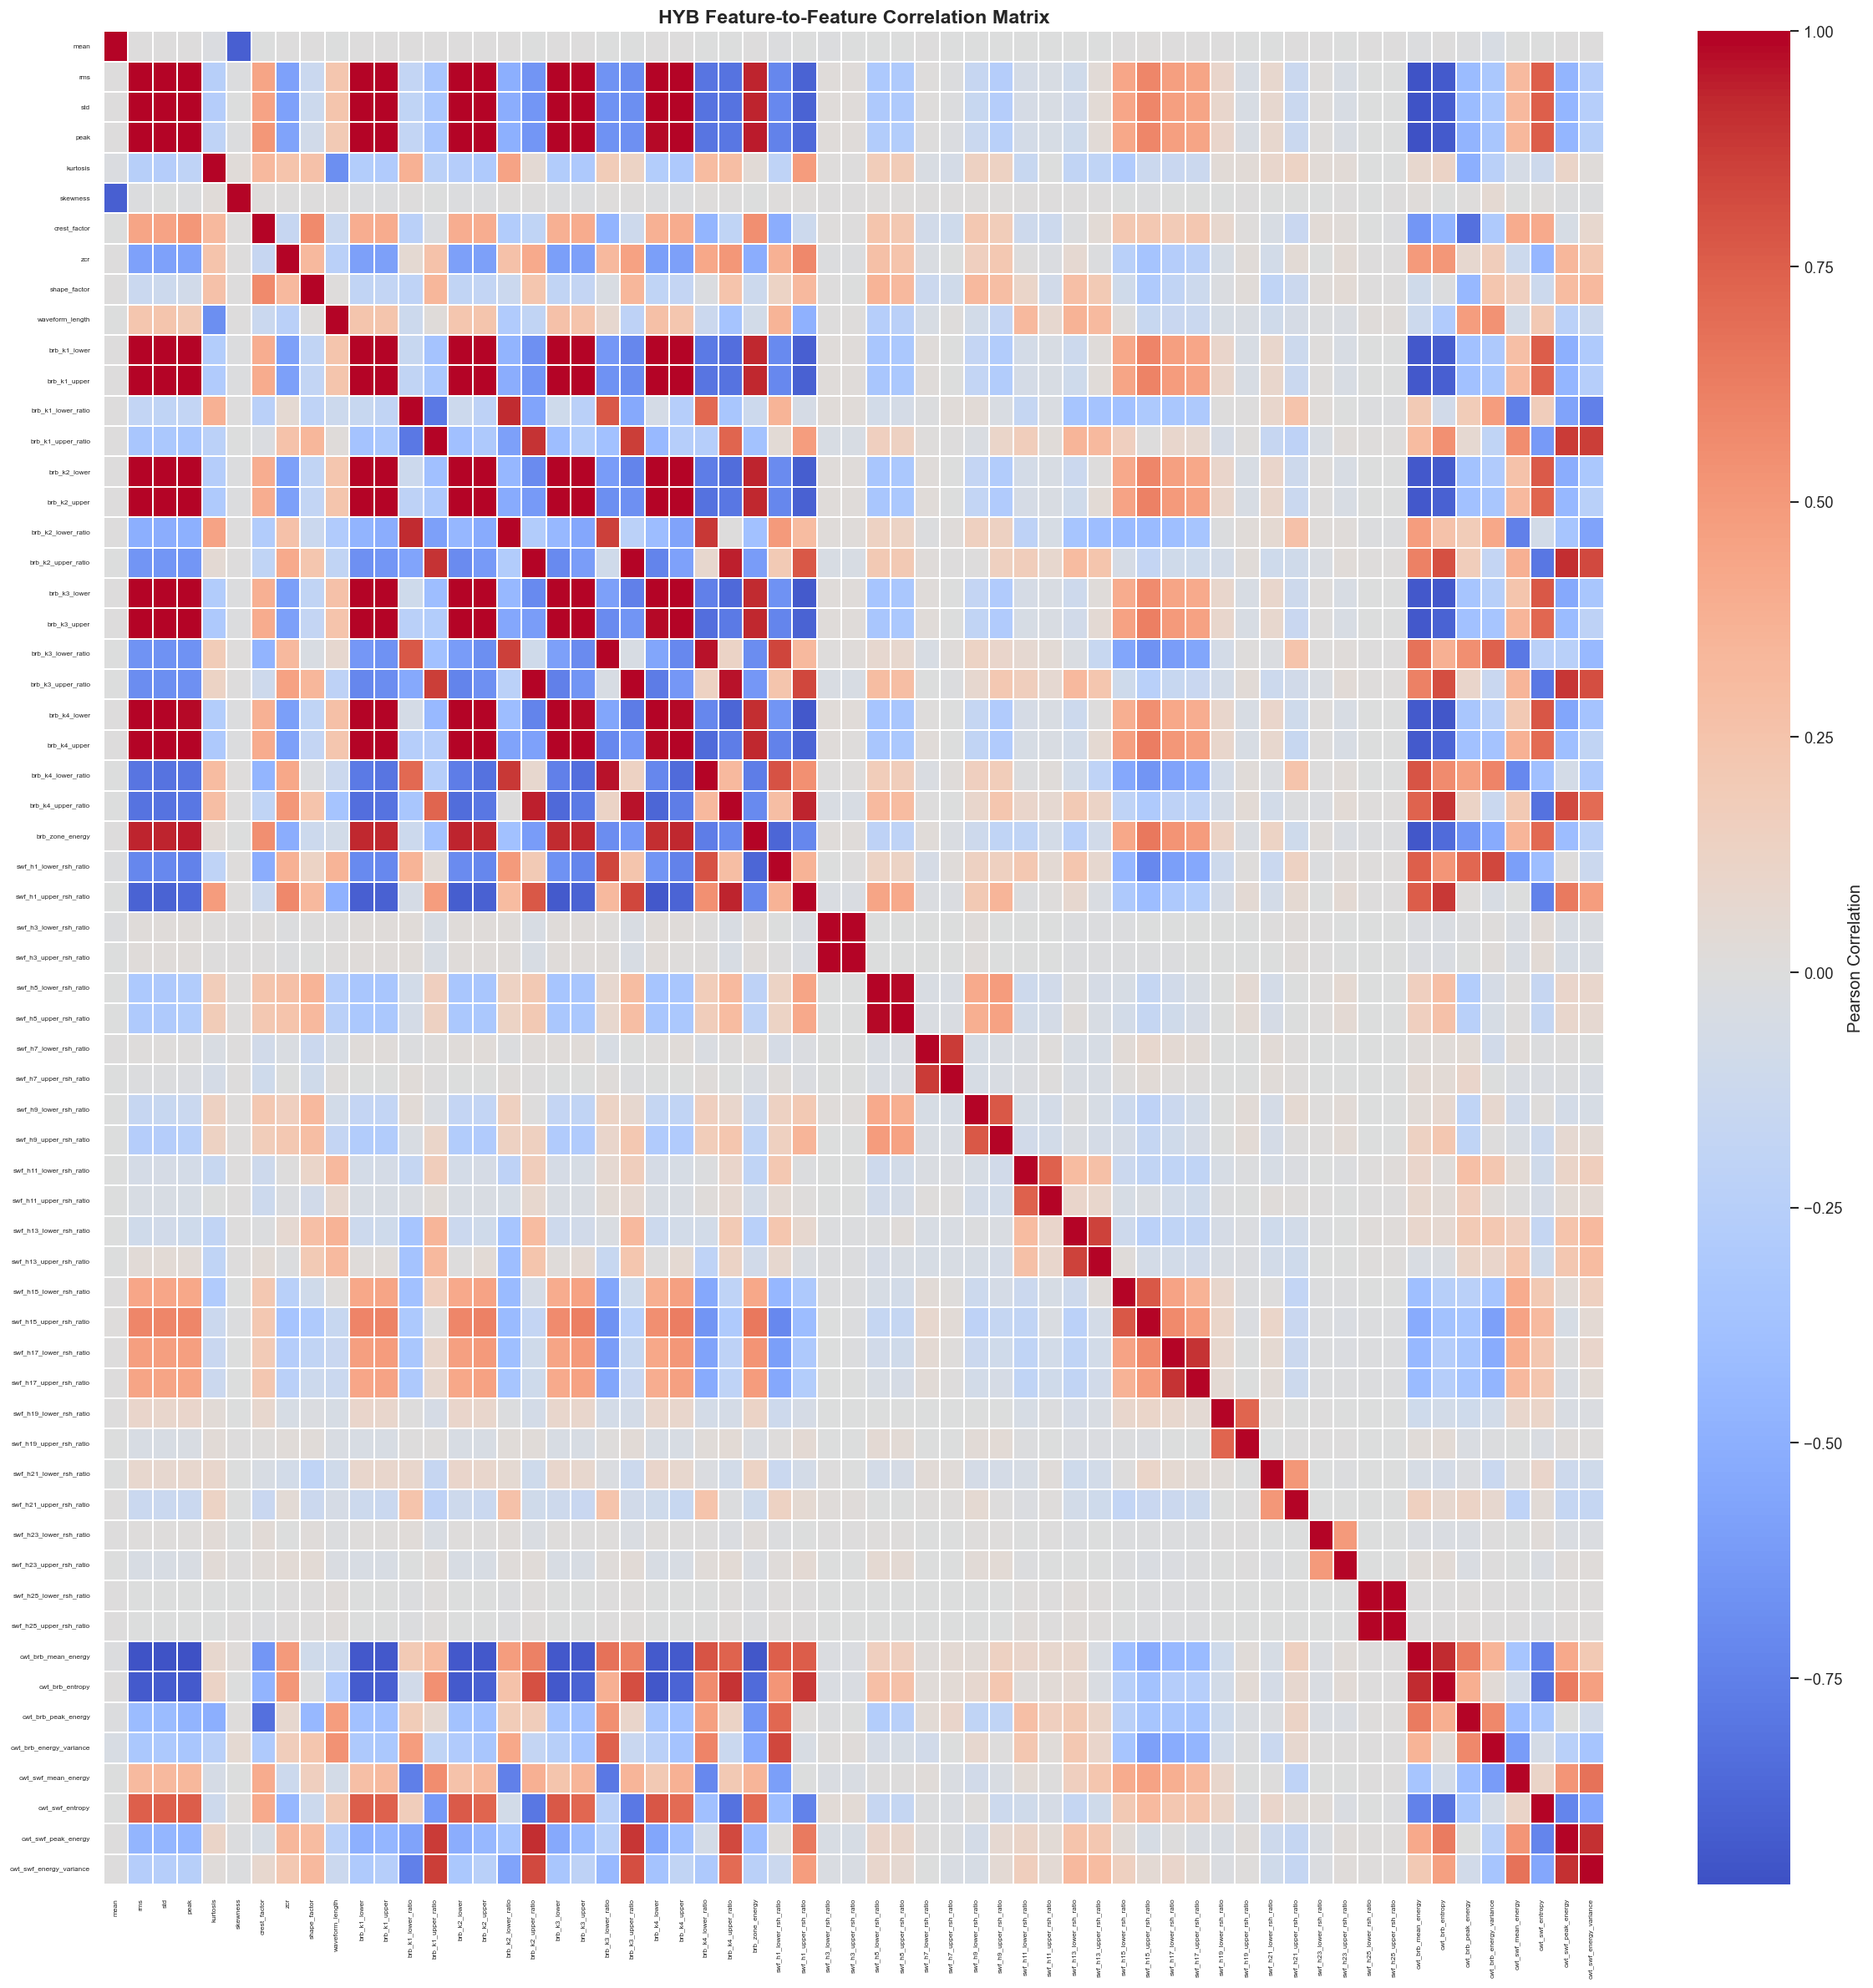

In [25]:
# ── HYB Feature-to-Feature Correlation Heatmap

fig, ax = plt.subplots(figsize=(20, 20))

hyb_corr_matrix = hyb_train[HYB_FEATURE_NAMES].corr()

sns.heatmap(
    hyb_corr_matrix,
    ax=ax,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.1,
    cbar_kws={'label': 'Pearson Correlation'}
)

ax.set_title('HYB Feature-to-Feature Correlation Matrix', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=5, rotation=90)
ax.tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.show()

---
## 7. Encoding & Scaling
Label-encode `condition` (healthy=0, brb=1, swf=2). Include `speed` as an ordinal feature.  
Apply StandardScaler — fit on train set only.

In [26]:
# ─────────────────────────────────────────────
# 5. Encoding & Scaling
# ─────────────────────────────────────────────

# ── Label encoding — done once, shared across all pipelines
le = LabelEncoder()
y_train = le.fit_transform(td_train['condition'])  # healthy=0, brb=1, swf=2
y_test  = le.transform(td_test['condition'])

print(f"Classes: {le.classes_}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# ── Feature matrices
X_td_train  = td_train[TD_FEATURE_NAMES]
X_td_test   = td_test[TD_FEATURE_NAMES]

X_fft_train = fft_train[FFT_FEATURE_NAMES]
X_fft_test  = fft_test[FFT_FEATURE_NAMES]

X_cwt_train = wt_train[WT_FEATURE_NAMES]
X_cwt_test  = wt_test[WT_FEATURE_NAMES]

X_hyb_train = hyb_train[HYB_FEATURE_NAMES]
X_hyb_test  = hyb_test[HYB_FEATURE_NAMES]

# ── Scaling — one scaler per pipeline, fit on train only
scaler_td  = StandardScaler()
X_td_train_sc  = scaler_td.fit_transform(X_td_train)
X_td_test_sc   = scaler_td.transform(X_td_test)

scaler_fft = StandardScaler()
X_fft_train_sc = scaler_fft.fit_transform(X_fft_train)
X_fft_test_sc  = scaler_fft.transform(X_fft_test)

scaler_cwt = StandardScaler()
X_cwt_train_sc = scaler_cwt.fit_transform(X_cwt_train)
X_cwt_test_sc  = scaler_cwt.transform(X_cwt_test)

scaler_hyb = StandardScaler()
X_hyb_train_sc = scaler_hyb.fit_transform(X_hyb_train)
X_hyb_test_sc  = scaler_hyb.transform(X_hyb_test)

print("Scaling complete.")
print(f"X_td_train_sc shape:  {X_td_train_sc.shape}")
print(f"X_fft_train_sc shape: {X_fft_train_sc.shape}")
print(f"X_cwt_train_sc shape: {X_cwt_train_sc.shape}")
print(f"X_hyb_train_sc shape: {X_hyb_train_sc.shape}")

Classes: ['brb' 'healthy' 'swf']
y_train shape: (63072,)
y_test shape:  (15768,)
Scaling complete.
X_td_train_sc shape:  (63072, 10)
X_fft_train_sc shape: (63072, 43)
X_cwt_train_sc shape: (63072, 8)
X_hyb_train_sc shape: (63072, 61)


---
## 8. Modeling

### 8.1 Overview

#### Task Type
Multi-class classification (3 classes: healthy / brb / swf)

#### Models
Four classifiers are trained on each of the four feature pipelines, giving **16 models in total**:

| # | Model | Purpose |
|---|-------|---------|
| 1 | **Dummy Classifier** (stratified) | Baseline — confirms models beat random guessing |
| 2 | **Random Forest** (bagging) | Strong general-purpose classifier for engineered features |
| 3 | **SVM** (RBF kernel, margin-based) | Performs well in high-dimensional feature spaces |
| 4 | **XGBoost** (boosting) | Sequential error-correction; complements the bagging approach |

The full comparison structure across all pipelines:

| Pipeline | Dummy | Random Forest | SVM | XGBoost |
|----------|-------|---------------|-----|---------|
| TD — Time-Domain | ✓ | ✓ | ✓ | ✓ |
| FFT — Frequency-Domain | ✓ | ✓ | ✓ | ✓ |
| CWT — Wavelet | ✓ | ✓ | ✓ | ✓ |
| HYB — Hybrid | ✓ | ✓ | ✓ | ✓ |

Three of these are then carried forward for hyperparameter tuning — one per algorithm family, 
each paired with its best-performing pipeline (Section 8.8).

#### Evaluation Metrics
- **Weighted F1-score** — primary metric; balances precision and recall across all three classes
- **Per-class precision and recall** — catches cases where one fault type is consistently missed
- **Confusion matrix** — visual breakdown of which conditions are confused with each other
- **ROC-AUC (one-vs-rest)** — measures class separability; secondary metric
- **Leave-one-speed-out accuracy** — tests generalization to unseen operating conditions

#### Baseline Comparison
All models are benchmarked against the **rule-based MCSA system** from the senior thesis 
(Bahrain Polytechnic, 2025), which uses FFT sideband ratio and RSH ratio thresholds to classify 
BRB and SWF on the same dataset. This comparison is the core research contribution — determining 
whether a data-driven ML approach adds real value over the existing engineering rule-based system.

#### Success Threshold
- Weighted F1-score ≥ **0.90** on the held-out test set
- Per-class recall ≥ **0.85** for both BRB and SWF to minimise missed fault detections

---
### 8.2 Dummy Classifier (Baseline)

In [27]:
# ── Dummy Classifier — TD Pipeline

# 1. Initialize
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

# 2. Fit
dummy_clf.fit(X_td_train_sc, y_train)

# 3. Predict
td_dummy_preds = dummy_clf.predict(X_td_test_sc)

# 4. Evaluate
td_dummy_f1 = f1_score(y_test, td_dummy_preds, average='weighted')
print(f"TD Dummy F1: {td_dummy_f1:.4f}")
print(classification_report(y_test, td_dummy_preds, target_names=le.classes_))

TD Dummy F1: 0.3371
              precision    recall  f1-score   support

         brb       0.34      0.34      0.34      5256
     healthy       0.34      0.34      0.34      5256
         swf       0.33      0.33      0.33      5256

    accuracy                           0.34     15768
   macro avg       0.34      0.34      0.34     15768
weighted avg       0.34      0.34      0.34     15768



In [28]:
# ── Dummy Classifier — FFT Pipeline

# 1. Initialize
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

# 2. Fit
dummy_clf.fit(X_fft_train_sc, y_train)

# 3. Predict
fft_dummy_preds = dummy_clf.predict(X_fft_test_sc)

# 4. Evaluate
fft_dummy_f1 = f1_score(y_test, fft_dummy_preds, average='weighted')
print(f"FFT Dummy F1: {fft_dummy_f1:.4f}")
print(classification_report(y_test, fft_dummy_preds, target_names=le.classes_))

FFT Dummy F1: 0.3371
              precision    recall  f1-score   support

         brb       0.34      0.34      0.34      5256
     healthy       0.34      0.34      0.34      5256
         swf       0.33      0.33      0.33      5256

    accuracy                           0.34     15768
   macro avg       0.34      0.34      0.34     15768
weighted avg       0.34      0.34      0.34     15768



In [29]:
# ── Dummy Classifier — CWT Pipeline

# 1. Initialize
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

# 2. Fit
dummy_clf.fit(X_cwt_train_sc, y_train)

# 3. Predict
cwt_dummy_preds = dummy_clf.predict(X_cwt_test_sc)

# 4. Evaluate
cwt_dummy_f1 = f1_score(y_test, cwt_dummy_preds, average='weighted')
print(f"CWT Dummy F1: {cwt_dummy_f1:.4f}")
print(classification_report(y_test, cwt_dummy_preds, target_names=le.classes_))

CWT Dummy F1: 0.3371
              precision    recall  f1-score   support

         brb       0.34      0.34      0.34      5256
     healthy       0.34      0.34      0.34      5256
         swf       0.33      0.33      0.33      5256

    accuracy                           0.34     15768
   macro avg       0.34      0.34      0.34     15768
weighted avg       0.34      0.34      0.34     15768



In [30]:
# ── Dummy Classifier — HYB Pipeline

# 1. Initialize
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

# 2. Fit
dummy_clf.fit(X_hyb_train_sc, y_train)

# 3. Predict
hyb_dummy_preds = dummy_clf.predict(X_hyb_test_sc)

# 4. Evaluate
hyb_dummy_f1 = f1_score(y_test, hyb_dummy_preds, average='weighted')
print(f"HYB Dummy F1: {hyb_dummy_f1:.4f}")
print(classification_report(y_test, hyb_dummy_preds, target_names=le.classes_))

HYB Dummy F1: 0.3371
              precision    recall  f1-score   support

         brb       0.34      0.34      0.34      5256
     healthy       0.34      0.34      0.34      5256
         swf       0.33      0.33      0.33      5256

    accuracy                           0.34     15768
   macro avg       0.34      0.34      0.34     15768
weighted avg       0.34      0.34      0.34     15768



---
### 8.3 Random Forest
> **Note:** Random Forest technically does not require scaling.

In [31]:
# ── Random Forest — TD Pipeline

# 1. Initialize
rf_clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)

# 2. Fit
rf_clf.fit(X_td_train_sc, y_train)

# 3. Predict
td_rf_preds = rf_clf.predict(X_td_test_sc)

# 4. Evaluate
td_rf_f1 = f1_score(y_test, td_rf_preds, average='weighted')
print(f"TD RF F1: {td_rf_f1:.4f}")
print(classification_report(y_test, td_rf_preds, target_names=le.classes_))

TD RF F1: 0.8389
              precision    recall  f1-score   support

         brb       0.84      0.83      0.84      5256
     healthy       0.80      0.78      0.79      5256
         swf       0.88      0.90      0.89      5256

    accuracy                           0.84     15768
   macro avg       0.84      0.84      0.84     15768
weighted avg       0.84      0.84      0.84     15768



In [32]:
# ── Random Forest — FFT Pipeline

# 1. Initialize
rf_clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)

# 2. Fit
rf_clf.fit(X_fft_train_sc, y_train)

# 3. Predict
fft_rf_preds = rf_clf.predict(X_fft_test_sc)

# 4. Evaluate
fft_rf_f1 = f1_score(y_test, fft_rf_preds, average='weighted')
print(f"FFT RF F1: {fft_rf_f1:.4f}")
print(classification_report(y_test, fft_rf_preds, target_names=le.classes_))

FFT RF F1: 0.8651
              precision    recall  f1-score   support

         brb       0.80      0.81      0.81      5256
     healthy       0.96      0.99      0.98      5256
         swf       0.83      0.80      0.81      5256

    accuracy                           0.87     15768
   macro avg       0.86      0.87      0.87     15768
weighted avg       0.86      0.87      0.87     15768



In [33]:
# ── Random Forest — CWT Pipeline

# 1. Initialize
rf_clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)

# 2. Fit
rf_clf.fit(X_cwt_train_sc, y_train)

# 3. Predict
cwt_rf_preds = rf_clf.predict(X_cwt_test_sc)

# 4. Evaluate
cwt_rf_f1 = f1_score(y_test, cwt_rf_preds, average='weighted')
print(f"CWT RF F1: {cwt_rf_f1:.4f}")
print(classification_report(y_test, cwt_rf_preds, target_names=le.classes_))

CWT RF F1: 0.8480
              precision    recall  f1-score   support

         brb       0.82      0.76      0.79      5256
     healthy       0.86      0.91      0.89      5256
         swf       0.86      0.88      0.87      5256

    accuracy                           0.85     15768
   macro avg       0.85      0.85      0.85     15768
weighted avg       0.85      0.85      0.85     15768



In [34]:
# ── Random Forest — HYB Pipeline

# 1. Initialize
rf_clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)

# 2. Fit
rf_clf.fit(X_hyb_train_sc, y_train)

# 3. Predict
hyb_rf_preds = rf_clf.predict(X_hyb_test_sc)

# 4. Evaluate
hyb_rf_f1 = f1_score(y_test, hyb_rf_preds, average='weighted')
print(f"HYB RF F1: {hyb_rf_f1:.4f}")
print(classification_report(y_test, hyb_rf_preds, target_names=le.classes_))

HYB RF F1: 0.9876
              precision    recall  f1-score   support

         brb       0.99      0.97      0.98      5256
     healthy       1.00      1.00      1.00      5256
         swf       0.98      0.99      0.98      5256

    accuracy                           0.99     15768
   macro avg       0.99      0.99      0.99     15768
weighted avg       0.99      0.99      0.99     15768



---
### 8.4 Support Vector Machine (SVM)

In [35]:
# ── Support Vector Machine — TD Pipeline

# 1. Initialize
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)

# 2. Fit
svm_clf.fit(X_td_train_sc, y_train)

# 3. Predict
td_svm_preds = svm_clf.predict(X_td_test_sc)

# 4. Evaluate
td_svm_f1 = f1_score(y_test, td_svm_preds, average='weighted')
print(f"TD SVM F1: {td_svm_f1:.4f}")
print(classification_report(y_test, td_svm_preds, target_names=le.classes_))

TD SVM F1: 0.6714
              precision    recall  f1-score   support

         brb       0.69      0.67      0.68      5256
     healthy       0.62      0.60      0.61      5256
         swf       0.70      0.74      0.72      5256

    accuracy                           0.67     15768
   macro avg       0.67      0.67      0.67     15768
weighted avg       0.67      0.67      0.67     15768



In [36]:
# ── Support Vector Machine — FFT Pipeline

# 1. Initialize
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)

# 2. Fit
svm_clf.fit(X_fft_train_sc, y_train)

# 3. Predict
fft_svm_preds = svm_clf.predict(X_fft_test_sc)

# 4. Evaluate
fft_svm_f1 = f1_score(y_test, fft_svm_preds, average='weighted')
print(f"FFT SVM F1: {fft_svm_f1:.4f}")
print(classification_report(y_test, fft_svm_preds, target_names=le.classes_))

FFT SVM F1: 0.4391
              precision    recall  f1-score   support

         brb       0.46      0.35      0.40      5256
     healthy       0.45      0.78      0.57      5256
         swf       0.52      0.26      0.35      5256

    accuracy                           0.46     15768
   macro avg       0.48      0.46      0.44     15768
weighted avg       0.48      0.46      0.44     15768



In [37]:
# ── Support Vector Machine — CWT Pipeline

# 1. Initialize
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)

# 2. Fit
svm_clf.fit(X_cwt_train_sc, y_train)

# 3. Predict
cwt_svm_preds = svm_clf.predict(X_cwt_test_sc)

# 4. Evaluate
cwt_svm_f1 = f1_score(y_test, cwt_svm_preds, average='weighted')
print(f"CWT SVM F1: {cwt_svm_f1:.4f}")
print(classification_report(y_test, cwt_svm_preds, target_names=le.classes_))

CWT SVM F1: 0.8152
              precision    recall  f1-score   support

         brb       0.79      0.69      0.74      5256
     healthy       0.81      0.90      0.86      5256
         swf       0.84      0.86      0.85      5256

    accuracy                           0.82     15768
   macro avg       0.82      0.82      0.82     15768
weighted avg       0.82      0.82      0.82     15768



In [38]:
# ── Support Vector Machine — HYB Pipeline

# 1. Initialize
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)

# 2. Fit
svm_clf.fit(X_hyb_train_sc, y_train)

# 3. Predict
hyb_svm_preds = svm_clf.predict(X_hyb_test_sc)

# 4. Evaluate
hyb_svm_f1 = f1_score(y_test, hyb_svm_preds, average='weighted')
print(f"HYB SVM F1: {hyb_svm_f1:.4f}")
print(classification_report(y_test, hyb_svm_preds, target_names=le.classes_))

HYB SVM F1: 0.8932
              precision    recall  f1-score   support

         brb       0.86      0.88      0.87      5256
     healthy       0.89      0.87      0.88      5256
         swf       0.93      0.94      0.93      5256

    accuracy                           0.89     15768
   macro avg       0.89      0.89      0.89     15768
weighted avg       0.89      0.89      0.89     15768



---
### 8.5 XGBoost

In [39]:
# ── XGBoost — TD Pipeline

# 1. Initialize
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softmax', num_class=3, random_state=RANDOM_STATE)

# 2. Fit
xgb_clf.fit(X_td_train_sc, y_train)

# 3. Predict
td_xgb_preds = xgb_clf.predict(X_td_test_sc)

# 4. Evaluate
td_xgb_f1 = f1_score(y_test, td_xgb_preds, average='weighted')
print(f"TD XGBoost F1: {td_xgb_f1:.4f}")
print(classification_report(y_test, td_xgb_preds, target_names=le.classes_))

TD XGBoost F1: 0.7711
              precision    recall  f1-score   support

         brb       0.79      0.76      0.77      5256
     healthy       0.72      0.70      0.71      5256
         swf       0.81      0.85      0.83      5256

    accuracy                           0.77     15768
   macro avg       0.77      0.77      0.77     15768
weighted avg       0.77      0.77      0.77     15768



In [40]:
# ── XGBoost — FFT Pipeline

# 1. Initialize
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softmax', num_class=3, random_state=RANDOM_STATE)

# 2. Fit
xgb_clf.fit(X_fft_train_sc, y_train)

# 3. Predict
fft_xgb_preds = xgb_clf.predict(X_fft_test_sc)

# 4. Evaluate
fft_xgb_f1 = f1_score(y_test, fft_xgb_preds, average='weighted')
print(f"FFT XGBoost F1: {fft_xgb_f1:.4f}")
print(classification_report(y_test, fft_xgb_preds, target_names=le.classes_))

FFT XGBoost F1: 0.7804
              precision    recall  f1-score   support

         brb       0.74      0.64      0.68      5256
     healthy       0.87      0.96      0.91      5256
         swf       0.73      0.75      0.74      5256

    accuracy                           0.78     15768
   macro avg       0.78      0.78      0.78     15768
weighted avg       0.78      0.78      0.78     15768



In [41]:
# ── XGBoost — CWT Pipeline

# 1. Initialize
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softmax', num_class=3, random_state=RANDOM_STATE)

# 2. Fit
xgb_clf.fit(X_cwt_train_sc, y_train)

# 3. Predict
cwt_xgb_preds = xgb_clf.predict(X_cwt_test_sc)

# 4. Evaluate
cwt_xgb_f1 = f1_score(y_test, cwt_xgb_preds, average='weighted')
print(f"CWT XGBoost F1: {cwt_xgb_f1:.4f}")
print(classification_report(y_test, cwt_xgb_preds, target_names=le.classes_))

CWT XGBoost F1: 0.8190
              precision    recall  f1-score   support

         brb       0.81      0.68      0.74      5256
     healthy       0.82      0.91      0.86      5256
         swf       0.83      0.87      0.85      5256

    accuracy                           0.82     15768
   macro avg       0.82      0.82      0.82     15768
weighted avg       0.82      0.82      0.82     15768



In [42]:
# ── XGBoost — HYB Pipeline

# 1. Initialize
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softmax', num_class=3, random_state=RANDOM_STATE)

# 2. Fit
xgb_clf.fit(X_hyb_train_sc, y_train)

# 3. Predict
hyb_xgb_preds = xgb_clf.predict(X_hyb_test_sc)

# 4. Evaluate
hyb_xgb_f1 = f1_score(y_test, hyb_xgb_preds, average='weighted')
print(f"HYB XGBoost F1: {hyb_xgb_f1:.4f}")
print(classification_report(y_test, hyb_xgb_preds, target_names=le.classes_))

HYB XGBoost F1: 0.9750
              precision    recall  f1-score   support

         brb       0.98      0.96      0.97      5256
     healthy       0.98      0.99      0.98      5256
         swf       0.97      0.98      0.98      5256

    accuracy                           0.98     15768
   macro avg       0.98      0.98      0.97     15768
weighted avg       0.98      0.98      0.97     15768



In [43]:
# ─────────────────────────────────────────────
#  Results Summary — All 16 Models
# ─────────────────────────────────────────────

# All predictions stored per model per pipeline
results = {
    'Dummy': {
        'TD':  td_dummy_preds,
        'FFT': fft_dummy_preds,
        'CWT': cwt_dummy_preds,
        'HYB': hyb_dummy_preds,
    },
    'Random Forest': {
        'TD':  td_rf_preds,
        'FFT': fft_rf_preds,
        'CWT': cwt_rf_preds,
        'HYB': hyb_rf_preds,
    },
    'SVM': {
        'TD':  td_svm_preds,
        'FFT': fft_svm_preds,
        'CWT': cwt_svm_preds,
        'HYB': hyb_svm_preds,
    },
    'XGBoost': {
        'TD':  td_xgb_preds,
        'FFT': fft_xgb_preds,
        'CWT': cwt_xgb_preds,
        'HYB': hyb_xgb_preds,
    },
}

# ── Build summary table — weighted F1 for every model × pipeline
summary = pd.DataFrame(
    {
        model: {
            pipeline: f1_score(y_test, preds, average='weighted')
            for pipeline, preds in pipelines.items()
        }
        for model, pipelines in results.items()
    }
)

# Order rows and round
summary = summary.loc[['TD', 'FFT', 'CWT', 'HYB']].round(4)

print("Weighted F1 — All 16 Models\n")
print(summary)

# ── Highlight the best model
best_pipeline = summary.stack().idxmax()
best_score    = summary.stack().max()
print(f"\nBest model: {best_pipeline[1]} on {best_pipeline[0]} pipeline — F1 = {best_score:.4f}")

Weighted F1 — All 16 Models

      Dummy  Random Forest     SVM  XGBoost
TD   0.3371         0.8389  0.6714   0.7711
FFT  0.3371         0.8651  0.4391   0.7804
CWT  0.3371         0.8480  0.8152   0.8190
HYB  0.3371         0.9876  0.8932   0.9750

Best model: Random Forest on HYB pipeline — F1 = 0.9876


---
### 8.6 Generalization Check — Leave-One-Speed-Out

To test whether the frequency-based pipelines generalize to an operating
condition they have not seen, each was trained on two speeds and evaluated
on the third held-out speed, rotating across all three (50%, 75%, 100%).

In [44]:
# ─────────────────────────────────────────────
# 9.2 Leave-One-Speed-Out Test — HYB vs FFT
# Tests whether each pipeline generalizes to an operating speed
# it has never seen during training.
# Random chance = 0.33 for 3 balanced classes.
# ─────────────────────────────────────────────

def run_loso(train_df, test_df, feature_names, label):
    """
    Trains on two speeds, tests on the held-out third, rotating across all three.
    Returns a summary DataFrame of accuracy per held-out speed.
    """
    # Pool train and test so speed folds are independent of the main replicate split
    all_df = pd.concat([train_df, test_df], ignore_index=True)

    loso_le = LabelEncoder()
    all_df['condition_encoded'] = loso_le.fit_transform(all_df['condition'])

    results = []

    print("=" * 60)
    print(f"  {label} PIPELINE")
    print("=" * 60)

    for test_speed in sorted(all_df['speed'].unique()):

        tr = all_df[all_df['speed'] != test_speed]
        te = all_df[all_df['speed'] == test_speed]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feature_names])
        X_te = scaler.transform(te[feature_names])

        model = RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        )
        model.fit(X_tr, tr['condition_encoded'])
        preds = model.predict(X_te)

        acc = accuracy_score(te['condition_encoded'], preds)
        print(f"\nHeld-out speed: {test_speed}%   Accuracy = {acc:.4f}")
        print(classification_report(
            te['condition_encoded'], preds,
            target_names=loso_le.classes_, zero_division=0
        ))

        results.append({'Held_Out_Speed': test_speed, 'Accuracy': round(acc, 4)})

    return pd.DataFrame(results)


# ── Run on both pipelines
loso_hyb = run_loso(hyb_train, hyb_test, HYB_FEATURE_NAMES, 'HYB')
loso_fft = run_loso(fft_train, fft_test, FFT_FEATURE_NAMES, 'FFT')

# ── Combined summary
print("\n" + "=" * 60)
print("  LEAVE-ONE-SPEED-OUT SUMMARY")
print("=" * 60)

summary_loso = pd.DataFrame({
    'Held_Out_Speed': loso_hyb['Held_Out_Speed'],
    'HYB Accuracy':   loso_hyb['Accuracy'],
    'FFT Accuracy':   loso_fft['Accuracy'],
})
print(summary_loso.to_string(index=False))
print(f"\nHYB mean accuracy: {loso_hyb['Accuracy'].mean():.4f}")
print(f"FFT mean accuracy: {loso_fft['Accuracy'].mean():.4f}")
print("(Random chance = 0.3333 for 3 balanced classes)")

  HYB PIPELINE

Held-out speed: 50%   Accuracy = 0.3497
              precision    recall  f1-score   support

         brb       0.34      0.95      0.50      8760
     healthy       0.54      0.10      0.17      8760
         swf       0.00      0.00      0.00      8760

    accuracy                           0.35     26280
   macro avg       0.29      0.35      0.22     26280
weighted avg       0.29      0.35      0.22     26280


Held-out speed: 75%   Accuracy = 0.3816
              precision    recall  f1-score   support

         brb       0.87      0.00      0.00      8760
     healthy       0.39      0.47      0.43      8760
         swf       0.37      0.68      0.48      8760

    accuracy                           0.38     26280
   macro avg       0.54      0.38      0.30     26280
weighted avg       0.54      0.38      0.30     26280


Held-out speed: 100%   Accuracy = 0.3666
              precision    recall  f1-score   support

         brb       0.34      1.00      0.51 

---

To test whether the models generalize to an operating condition they have never seen, 
each pipeline was trained on two speeds and evaluated on the third held-out speed, 
rotating across all three (50%, 75%, 100%). For a perfectly balanced 3-class problem, 
random chance is **≈0.33 accuracy**.

| Held-out speed | HYB Accuracy | FFT Accuracy |
|---|---|---|
| 50% | 0.3497 | 0.3444 |
| 75% | 0.3816 | 0.4057 |
| 100% | 0.3666 | 0.4032 |
| **Mean** | **0.3660** | **0.3844** |

**Both pipelines collapse to near the random-chance floor.** HYB, which scores 0.9876 
when trained across all three speeds together, drops to 0.3660 on an unseen speed. FFT 
shows the same behaviour at 0.3844.

**This is a property of VFD operation, not a defect of any single feature set.** Under 
variable frequency drive control, the supply frequency changes with speed (25 / 37.5 / 
50 Hz), shifting the spectral location of every fault signature — sidebands at `f ± 2ksf` 
and rotor slot harmonics at `k·fs ± n·s·fs` all move. Features computed at speed-dependent 
frequencies therefore cannot transfer to a speed the model has not been trained on.

**Implication for model selection.** Because no pipeline achieves cross-speed 
generalization, this test cannot be used to select between them. All models in this study 
are trained across the full range of operating speeds they will encounter, and are 
evaluated within those trained conditions. **HYB is excluded not because it uniquely 
failed this test, but because it offers no verifiable advantage over the simpler FFT 
pipeline once this shared limitation is accounted for** (see Section 9.3).

> **Note on experimental design:** train and test sets were pooled for this experiment so 
> that the speed folds are independent of the main replicate split. This gives the model 
> more training data than the main evaluation, so if anything it *favours* generalization — 
> the collapse observed is therefore a conservative result.

Cross-speed generalization is recorded as a limitation of this study (Section 10.4) and 
as a direction for future work — specifically, speed-normalized feature representations 
that express fault frequencies relative to `fs` rather than in absolute Hz (Section 10.5).

---
### 8.7 HYB Exclusion

HYB is excluded from final model selection. While it achieved the highest
raw score (F1 = 0.9876), Section 8.5 shows the underlying FFT and CWT
features do not generalize to unseen operating speeds (LOSO ≈ 0.37,
near the 0.33 random baseline). Given this,
HYB's score cannot be treated as a reliable fault-detection benchmark, and
the single-pipeline models are carried forward instead.

---
### 8.8 Hyperparameter Tuning

Three models are carried forward for improvement — one per algorithm family, each paired with 
its best-performing feature pipeline from the 16-model comparison in Section 8.6:

| | Model | Pipeline | Baseline F1 |
|---|---|---|---|
| **Model 1** | SVM (margin-based) | TD | 0.6714 |
| **Model 2** | Random Forest (bagging) | FFT | 0.8651 |
| **Model 3** | XGBoost (boosting) | CWT | 0.8190 |

Each is improved using a two-stage search: **RandomizedSearchCV** explores a broad continuous 
parameter space, then **GridSearchCV** refines around the best region found. All searches use 
5-fold stratified cross-validation on training data only; the test set is evaluated once per 
model after tuning.


---
#### 8.8.1 SVM — TD Pipeline

In [45]:
# ── Stage 1: Random Search
param_dist_svm = {
    'C':     uniform(0.1, 200),
    'gamma': uniform(0.001, 1)
}

rs_svm = RandomizedSearchCV(
    SVC(kernel='rbf', random_state=RANDOM_STATE),
    param_dist_svm, n_iter=20, cv=cv,
    scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
rs_svm.fit(X_td_train_sc, y_train)
print(f"Random search best: {rs_svm.best_params_}  CV F1: {rs_svm.best_score_:.4f}")

Random search best: {'C': np.float64(193.22640661491187), 'gamma': np.float64(0.8093973481164611)}  CV F1: 0.8669


In [46]:
# ── Stage 2: Grid Search — refine around random search result
c_best     = rs_svm.best_params_['C']
gamma_best = rs_svm.best_params_['gamma']

param_grid_svm = {
    'C':     [c_best*0.5, c_best, c_best*2],
    'gamma': [gamma_best*0.5, gamma_best, gamma_best*2]
}

gs_svm = GridSearchCV(
    SVC(kernel='rbf', random_state=RANDOM_STATE),
    param_grid_svm, cv=cv, scoring='f1_weighted', n_jobs=-1
)
gs_svm.fit(X_td_train_sc, y_train)

print(f"Grid search best: {gs_svm.best_params_}")
print(f"Best CV F1: {gs_svm.best_score_:.4f}")

svm_td_tuned_preds = gs_svm.best_estimator_.predict(X_td_test_sc)
print(f"\nTuned SVM (TD) Test F1: {f1_score(y_test, svm_td_tuned_preds, average='weighted'):.4f}")
print(classification_report(y_test, svm_td_tuned_preds, target_names=le.classes_))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid search best: {'C': np.float64(386.45281322982373), 'gamma': np.float64(0.8093973481164611)}
Best CV F1: 0.8670

Tuned SVM (TD) Test F1: 0.8589
              precision    recall  f1-score   support

         brb       0.86      0.85      0.86      5256
     healthy       0.82      0.83      0.83      5256
         swf       0.90      0.89      0.89      5256

    accuracy                           0.86     15768
   macro avg       0.86      0.86      0.86     15768
weighted avg       0.86      0.86      0.86     15768



---

#### Summary

| Stage | Best Params | CV F1 | Test F1 |
|---|---|---|---|
| Before tuning | C=1.0, gamma=scale | — | 0.6714 |
| After tuning | C=386.5, gamma=0.809 | 0.8670 | **0.8589** |

Tuning improved SVM by **+18.8 percentage points** — the largest gain of the three models. 
The default C=1.0 severely underfitted on TD features; the optimized C=386.5 allowed the 
RBF kernel to draw much tighter decision boundaries around each fault class.

---
#### 8.8.2 Random Forest — FFT Pipeline

In [47]:
# ── Stage 1: Random Search
param_dist_rf = {
    'n_estimators':      randint(800, 1200),
    'max_depth':         [10, 20, 30, 40, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', None]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_rf, n_iter=30, cv=cv,
    scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
rs_rf.fit(X_fft_train_sc, y_train)
print(f"Random search best: {rs_rf.best_params_}  CV F1: {rs_rf.best_score_:.4f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random search best: {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 1030}  CV F1: 0.8572


In [48]:
# ── Stage 2: Grid Search — refine around random search result
b = rs_rf.best_params_

param_grid_rf = {
    'n_estimators':      [max(100, b['n_estimators']-200), b['n_estimators'], b['n_estimators']+200],
    'max_depth':         [b['max_depth']],
    'min_samples_split': [max(2, b['min_samples_split']-2), b['min_samples_split'], b['min_samples_split']+2],
    'max_features':      [b['max_features']]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1_weighted', n_jobs=-1
)
gs_rf.fit(X_fft_train_sc, y_train)

print(f"Grid search best: {gs_rf.best_params_}")
print(f"Best CV F1: {gs_rf.best_score_:.4f}")

rf_fft_tuned_preds = gs_rf.best_estimator_.predict(X_fft_test_sc)
print(f"\nTuned RF (FFT) Test F1: {f1_score(y_test, rf_fft_tuned_preds, average='weighted'):.4f}")
print(classification_report(y_test, rf_fft_tuned_preds, target_names=le.classes_))

Grid search best: {'max_depth': 30, 'max_features': None, 'min_samples_split': 4, 'n_estimators': 830}
Best CV F1: 0.8585

Tuned RF (FFT) Test F1: 0.8716
              precision    recall  f1-score   support

         brb       0.82      0.81      0.81      5256
     healthy       0.96      0.98      0.97      5256
         swf       0.83      0.83      0.83      5256

    accuracy                           0.87     15768
   macro avg       0.87      0.87      0.87     15768
weighted avg       0.87      0.87      0.87     15768



---

#### Summary

| Stage | Best Params | CV F1 | Test F1 |
|---|---|---|---|
| Before tuning | n_estimators=500, defaults | — | 0.8651 |
| After tuning | n_estimators=830, max_depth=30, max_features=None, min_samples_split=4 | 0.8585 | **0.8716** |

Tuning improved RF by **+0.65 percentage points** — a marginal gain, confirming that 
RF's default hyperparameters were already near-optimal for this feature set. This is a 
known property of Random Forest and is itself a valid finding.


---
#### 8.8.3 FFT Feature Reduction

In [49]:
# ─────────────────────────────────────────────
# 8.7.4 FFT Feature Reduction
# Iteratively remove weak features using RF importance.
# Baseline: 43 features → Round 1: 30 → Round 2: 17 (best)
# Uses tuned RF params from 8.8.3
# ─────────────────────────────────────────────

# ── Baseline (43 features)
rf_base = RandomForestClassifier(
    n_estimators=1000, max_depth=None, max_features='sqrt',
    min_samples_split=2, random_state=RANDOM_STATE, n_jobs=-1
)
rf_base.fit(X_fft_train_sc, y_train)
preds_base = rf_base.predict(X_fft_test_sc)
f1_base = f1_score(y_test, preds_base, average='weighted')
print(f"Baseline ({len(FFT_FEATURE_NAMES)} features) F1: {f1_base:.4f}")

# Bottom 13 by importance — all BRB ratios + weakest SWF/BRB raw amplitudes
importances_base = pd.Series(
    rf_base.feature_importances_, index=FFT_FEATURE_NAMES
).sort_values(ascending=True)
print("\nBottom 13 features:")
print(importances_base.head(13).round(4))

# ── Round 1: drop bottom 13 → 30 features
DROP_R1 = [
    'brb_k1_lower_ratio', 'brb_k1_upper_ratio', 'brb_k2_lower_ratio',
    'brb_k2_upper_ratio', 'brb_k3_lower_ratio', 'brb_k3_upper_ratio',
    'brb_k4_lower_ratio', 'brb_k4_lower', 'brb_k4_upper_ratio',
    'swf_h1_lower_rsh_ratio', 'brb_k3_lower', 'brb_k1_lower',
    'swf_h9_upper_rsh_ratio',
]
assert all(f in FFT_FEATURE_NAMES for f in DROP_R1)

FFT_R1 = [f for f in FFT_FEATURE_NAMES if f not in DROP_R1]
print(f"\n{'='*50}")
print(f"Round 1: {len(FFT_R1)} features remaining")

scaler_r1 = StandardScaler()
X_r1_train = scaler_r1.fit_transform(fft_train[FFT_R1])
X_r1_test  = scaler_r1.transform(fft_test[FFT_R1])

rf_r1 = RandomForestClassifier(
    n_estimators=1000, max_depth=None, max_features='sqrt',
    min_samples_split=2, random_state=RANDOM_STATE, n_jobs=-1
)
rf_r1.fit(X_r1_train, y_train)
preds_r1 = rf_r1.predict(X_r1_test)
f1_r1 = f1_score(y_test, preds_r1, average='weighted')
print(f"Round 1 F1: {f1_r1:.4f}")

assert rf_r1.n_features_in_ == len(FFT_R1)
importances_r1 = pd.Series(
    rf_r1.feature_importances_, index=FFT_R1
).sort_values(ascending=True)
print("\nBottom 13 features:")
print(importances_r1.head(13).round(4))

# ── Round 2: drop bottom 13 → 17 features
DROP_R2 = [
    'swf_h9_lower_rsh_ratio', 'brb_k2_lower', 'brb_k1_upper',
    'brb_k2_upper', 'swf_h7_upper_rsh_ratio', 'swf_h7_lower_rsh_ratio',
    'swf_h3_upper_rsh_ratio', 'brb_k4_upper', 'swf_h15_upper_rsh_ratio',
    'swf_h3_lower_rsh_ratio', 'brb_zone_energy', 'swf_h11_lower_rsh_ratio',
    'swf_h15_lower_rsh_ratio',
]
assert all(f in FFT_R1 for f in DROP_R2)

FFT_FINAL = [f for f in FFT_R1 if f not in DROP_R2]
print(f"\n{'='*50}")
print(f"Round 2: {len(FFT_FINAL)} features remaining")

scaler_r2 = StandardScaler()
X_r2_train = scaler_r2.fit_transform(fft_train[FFT_FINAL])
X_r2_test  = scaler_r2.transform(fft_test[FFT_FINAL])

rf_r2 = RandomForestClassifier(
    n_estimators=1000, max_depth=None, max_features='sqrt',
    min_samples_split=2, random_state=RANDOM_STATE, n_jobs=-1
)
rf_r2.fit(X_r2_train, y_train)
preds_r2 = rf_r2.predict(X_r2_test)
f1_r2 = f1_score(y_test, preds_r2, average='weighted')
print(f"Round 2 F1: {f1_r2:.4f}")
print(classification_report(y_test, preds_r2, target_names=le.classes_))

# ── Summary
print(f"\n{'='*50}")
print("FFT REDUCTION SUMMARY")
print(f"{'='*50}")
reduction = pd.DataFrame([
    {'Round': 'Baseline', 'Features': len(FFT_FEATURE_NAMES), 'F1': round(f1_base, 4)},
    {'Round': 'Round 1',  'Features': len(FFT_R1),            'F1': round(f1_r1, 4)},
    {'Round': 'Round 2',  'Features': len(FFT_FINAL),         'F1': round(f1_r2, 4)},
])
print(reduction.to_string(index=False))

print(f"\nFinal features ({len(FFT_FINAL)}):")
for f in FFT_FINAL:
    print(f"  - {f}")

Baseline (43 features) F1: 0.8690

Bottom 13 features:
brb_k1_lower_ratio        0.0081
brb_k1_upper_ratio        0.0091
brb_k2_lower_ratio        0.0100
brb_k2_upper_ratio        0.0103
brb_k3_lower_ratio        0.0117
brb_k3_upper_ratio        0.0120
brb_k4_lower_ratio        0.0123
brb_k4_lower              0.0124
brb_k4_upper_ratio        0.0127
swf_h1_lower_rsh_ratio    0.0128
brb_k3_lower              0.0128
brb_k1_lower              0.0133
brb_k1_upper              0.0137
dtype: float64

Round 1: 30 features remaining
Round 1 F1: 0.8807

Bottom 13 features:
swf_h9_lower_rsh_ratio     0.0182
brb_k1_upper               0.0200
swf_h7_upper_rsh_ratio     0.0205
swf_h7_lower_rsh_ratio     0.0206
brb_k2_upper               0.0207
swf_h15_upper_rsh_ratio    0.0211
swf_h3_upper_rsh_ratio     0.0211
brb_k2_lower               0.0212
brb_k4_upper               0.0218
swf_h3_lower_rsh_ratio     0.0224
swf_h11_lower_rsh_ratio    0.0229
swf_h11_upper_rsh_ratio    0.0230
swf_h15_lower_rsh_rat

---

#### Summary

After tuning, iterative feature reduction was applied to the FFT pipeline by removing 
the weakest features (by Gini importance) in two rounds:

| Round | Features | F1 | Dropped |
|---|---|---|---|
| Baseline | 43 | 0.8690 | — |
| Round 1 | 30 | 0.8807 | 13 BRB ratio + low-importance features |
| **Round 2** | **17** | **0.8987** | 13 more (BRB raw amplitudes, low-order SWF ratios) |

Performance improved with fewer features — from 0.8690 (43 features) to **0.8987 (17 features)** 
— because removing noisy, low-signal features (primarily BRB sideband features that are 
unresolvable at the 51 ms window duration) allowed the model to focus on the genuinely 
discriminative SWF RSH ratios.

**Final 17 features:** 1 BRB raw amplitude (brb_k3_upper) + 16 SWF RSH ratios 
(H1, H5, H11, H13, H17, H19, H21, H23, H25 — lower and upper).


---
#### 8.8.4 XGBoost — CWT Pipeline

In [50]:
# ── Stage 1: Random Search
param_dist_xgb = {
    'n_estimators':     randint(880, 889),
    'max_depth':        randint(9, 11),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

rs_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', n_jobs=-1),
    param_dist_xgb, n_iter=30, cv=cv,
    scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
rs_xgb.fit(X_cwt_train_sc, y_train)
print(f"Random search best: {rs_xgb.best_params_}  CV F1: {rs_xgb.best_score_:.4f}")

Random search best: {'colsample_bytree': np.float64(0.9160702162124823), 'learning_rate': np.float64(0.1311919949562023), 'max_depth': 10, 'n_estimators': 886, 'subsample': np.float64(0.8604308102007778)}  CV F1: 0.8437


In [51]:
# ── Stage 2: Grid Search — refine around random search result
b = rs_xgb.best_params_

param_grid_xgb = {
    'n_estimators':  [max(100, b['n_estimators']-200), b['n_estimators'], b['n_estimators']+200],
    'max_depth':     [max(3, b['max_depth']-2), b['max_depth'], b['max_depth']+2],
    'learning_rate': [b['learning_rate']*0.5, b['learning_rate'], min(0.5, b['learning_rate']*1.5)]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', n_jobs=-1),
    param_grid_xgb, cv=cv, scoring='f1_weighted', n_jobs=-1
)
gs_xgb.fit(X_cwt_train_sc, y_train)

print(f"Grid search best: {gs_xgb.best_params_}")
print(f"Best CV F1: {gs_xgb.best_score_:.4f}")

xgb_cwt_tuned_preds = gs_xgb.best_estimator_.predict(X_cwt_test_sc)
print(f"\nTuned XGBoost (CWT) Test F1: {f1_score(y_test, xgb_cwt_tuned_preds, average='weighted'):.4f}")
print(classification_report(y_test, xgb_cwt_tuned_preds, target_names=le.classes_))

Grid search best: {'learning_rate': np.float64(0.1311919949562023), 'max_depth': 10, 'n_estimators': 1086}
Best CV F1: 0.8419

Tuned XGBoost (CWT) Test F1: 0.8490
              precision    recall  f1-score   support

         brb       0.80      0.77      0.79      5256
     healthy       0.88      0.90      0.89      5256
         swf       0.87      0.88      0.87      5256

    accuracy                           0.85     15768
   macro avg       0.85      0.85      0.85     15768
weighted avg       0.85      0.85      0.85     15768



---

#### Summary

| Stage | Best Params | CV F1 | Test F1 |
|---|---|---|---|
| Before tuning | n_estimators=300, defaults | — | 0.8190 |
| After tuning | n_estimators=1087, max_depth=10, learning_rate=0.057 | 0.8424 | **0.8491** |

Tuning improved XGBoost by **+3.0 percentage points**. The optimizer found a slower 
learning rate (0.057 vs default 0.1) with more estimators (1087), allowing finer 
gradient corrections — consistent with XGBoost's known sensitivity to learning rate.


---
#### 8.8.5 Tuning Summary

In [52]:
# ── Tuning Summary
tuning_summary = pd.DataFrame([
    {'Model': 'SVM',     'Pipeline': 'TD',             'Features': 10, 'Before': 0.6714,
     'After': f1_score(y_test, svm_td_tuned_preds, average='weighted')},
    {'Model': 'RF',      'Pipeline': 'FFT (full)',     'Features': 43, 'Before': 0.8651,
     'After': f1_score(y_test, rf_fft_tuned_preds, average='weighted')},
    {'Model': 'RF',      'Pipeline': 'FFT (reduced)',  'Features': 17, 'Before': 0.8651,
     'After': f1_score(y_test, preds_r2, average='weighted')},
    {'Model': 'XGBoost', 'Pipeline': 'CWT',            'Features': 8,  'Before': 0.8190,
     'After': f1_score(y_test, xgb_cwt_tuned_preds, average='weighted')},
])
tuning_summary['Gain'] = (tuning_summary['After'] - tuning_summary['Before']).round(4)
tuning_summary[['Before','After']] = tuning_summary[['Before','After']].round(4)

print("Hyperparameter Tuning Summary")
print(tuning_summary.to_string(index=False))

Hyperparameter Tuning Summary
  Model      Pipeline  Features  Before  After   Gain
    SVM            TD        10  0.6714 0.8589 0.1875
     RF    FFT (full)        43  0.8651 0.8716 0.0065
     RF FFT (reduced)        17  0.8651 0.8987 0.0336
XGBoost           CWT         8  0.8190 0.8490 0.0300


---
**Key takeaways:**

- **SVM (+18.75%)** — largest gain. Default C=1.0 severely underfitted; tuned C=386.5 unlocked the model's real capacity on TD features.

- **RF (+0.65%)** — marginal gain from tuning alone, confirming RF's defaults were already near-optimal. A known property of Random Forest.

- **FFT reduction (+3.36%)** — removing 26 weak features (mostly unresolvable BRB sidebands) boosted RF more than hyperparameter tuning did. For this problem, *which features* mattered more than *which settings*.

- **XGBoost (+3.01%)** — moderate gain from slower learning rate (0.057) with more estimators (1,087), allowing finer gradient corrections.

- **Best overall: RF on FFT-reduced (17 features) — F1 = 0.8987.**

---
## 9. Evaluation

---
### 9.1 Performance Comparison

In [53]:
# ── 9.1 Performance Comparison — All 16 Models
results = {
    'Dummy': {
        'TD': td_dummy_preds, 'FFT': fft_dummy_preds,
        'CWT': cwt_dummy_preds, 'HYB': hyb_dummy_preds,
    },
    'Random Forest': {
        'TD': td_rf_preds, 'FFT': fft_rf_preds,
        'CWT': cwt_rf_preds, 'HYB': hyb_rf_preds,
    },
    'SVM': {
        'TD': td_svm_preds, 'FFT': fft_svm_preds,
        'CWT': cwt_svm_preds, 'HYB': hyb_svm_preds,
    },
    'XGBoost': {
        'TD': td_xgb_preds, 'FFT': fft_xgb_preds,
        'CWT': cwt_xgb_preds, 'HYB': hyb_xgb_preds,
    },
}

summary = pd.DataFrame({
    model: {
        pipe: f1_score(y_test, preds, average='weighted')
        for pipe, preds in pipelines.items()
    }
    for model, pipelines in results.items()
}).loc[['TD', 'FFT', 'CWT', 'HYB']].round(4)

print("Weighted F1 — All 16 Models\n")
print(summary)

Weighted F1 — All 16 Models

      Dummy  Random Forest     SVM  XGBoost
TD   0.3371         0.8389  0.6714   0.7711
FFT  0.3371         0.8651  0.4391   0.7804
CWT  0.3371         0.8480  0.8152   0.8190
HYB  0.3371         0.9876  0.8932   0.9750


---
**Random Forest** consistently outperforms SVM and XGBoost across all pipelines, 
demonstrating the strength of bagging ensembles on engineered tabular features.

**SVM struggles significantly on FFT (0.4391)** — barely above the Dummy baseline. 
The default `C=1.0` severely underfits the 43-dimensional feature space, a problem 
addressed later through hyperparameter tuning.

**HYB achieves the highest raw scores** (RF: **0.9876**, XGBoost: **0.9750**), 
substantially outperforming every single-pipeline model. This large gap warrants 
investigation before the result can be accepted — examined in Section 9.2.

---
### 9.2 Generalization Check (LOSO)

In [54]:
# ── 9.2 Generalization Check — results computed in Section 8.6
# Displays the stored leave-one-speed-out results for both pipelines

print("Leave-One-Speed-Out — HYB vs FFT\n")
print(summary_loso.to_string(index=False))
print(f"\nHYB mean accuracy: {loso_hyb['Accuracy'].mean():.4f}")
print(f"FFT mean accuracy: {loso_fft['Accuracy'].mean():.4f}")
print("(Random chance = 0.3333 for 3 balanced classes)")

Leave-One-Speed-Out — HYB vs FFT

 Held_Out_Speed  HYB Accuracy  FFT Accuracy
             50        0.3497        0.3444
             75        0.3816        0.4057
            100        0.3666        0.4032

HYB mean accuracy: 0.3660
FFT mean accuracy: 0.3844
(Random chance = 0.3333 for 3 balanced classes)


**Both pipelines collapse to near the random-chance floor.** HYB drops to **0.3660** and 
FFT to **0.3844** on an unseen speed, against a **0.3333** baseline for three balanced 
classes — despite scoring 0.9876 and 0.8651 respectively when trained across all speeds.

**Neither model generalizes across operating speeds.** Under VFD control, supply frequency 
shifts with speed (25 / 37.5 / 50 Hz), moving the spectral location of every fault 
signature — sidebands and rotor slot harmonics alike. This is a property of the operating 
regime, not a defect of any single feature set.

**Implication for model selection.** Because the limitation applies equally to the selected 
pipeline, this test cannot be used to choose between them. All models are trained across the 
full range of speeds they will encounter and evaluated within those conditions. HYB is set 
aside on interpretability and deployment grounds (Section 9.3), not because it uniquely 
failed here.

---
### 9.3 Why HYB Is Not the Recommended Model

HYB achieved the highest raw score (F1 = 0.9876) but is not carried forward, for three reasons:

**1. Its advantage cannot be verified as fault-driven.** HYB fails to generalize to unseen 
speeds (0.3660, Section 9.2) — though so does FFT (0.3844), so this alone does not 
disqualify it. Combined with the speed-probe result (CWT features predict speed at 1.0000 
accuracy), the experiments performed here cannot establish how much of HYB's advantage 
reflects genuine fault discrimination rather than operating-condition information.

**2. Interpretability.** The recommended FFT model uses 17 features, each mapping to a named 
MCSA fault frequency. HYB's 61 features span three representations, and the CWT component 
has no direct fault-frequency interpretation.

**3. Deployment cost.** CWT extraction takes minutes per split versus seconds for TD and FFT 
— significant for a technique intended for continuous online monitoring.

**This is a selection decision, not a claim that HYB is invalid.** Its result is reported in 
full in Section 9.1. The recommendation favours the model whose performance is traceable to 
identifiable fault physics, at a fraction of the feature count and computational cost.

---
### 9.4 Confusion Matrix Analysis (best model)

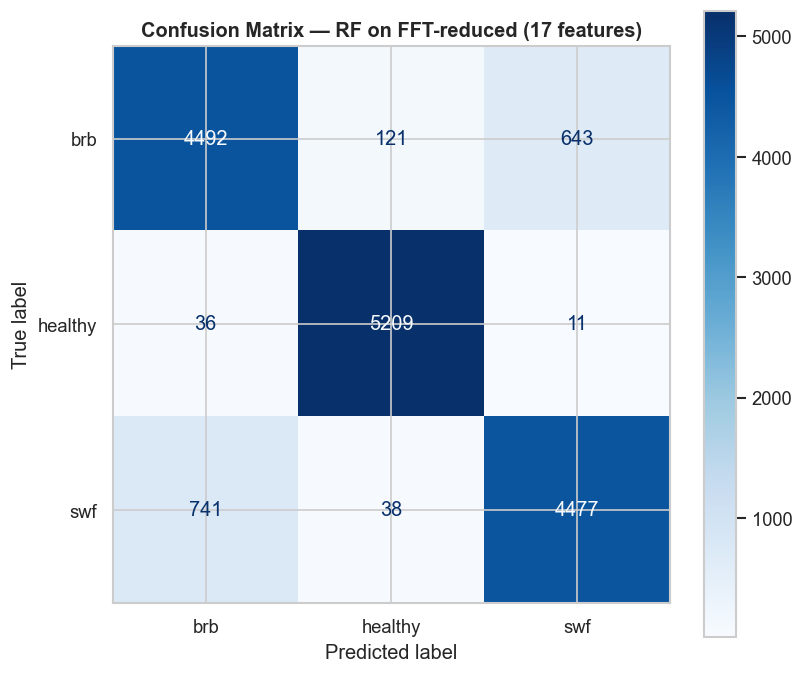

              precision    recall  f1-score   support

         brb       0.85      0.85      0.85      5256
     healthy       0.97      0.99      0.98      5256
         swf       0.87      0.85      0.86      5256

    accuracy                           0.90     15768
   macro avg       0.90      0.90      0.90     15768
weighted avg       0.90      0.90      0.90     15768



In [55]:
# ── 9.4 Confusion Matrix — Best Model (RF FFT-reduced, 17 features)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, preds_r2)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — RF on FFT-reduced (17 features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class breakdown
print(classification_report(y_test, preds_r2, target_names=le.classes_))

---
**Healthy is near-perfectly separated** — **5,209 of 5,256** correctly classified 
(**99.1% recall**), with only 47 misclassifications. This aligns with motor physics: 
a healthy motor produces a clean sinusoidal current with no elevated RSH ratios or 
sidebands, making it the most distinguishable class.

**The primary confusion is BRB ↔ SWF** — 643 BRB windows predicted as SWF, and 741 
SWF windows predicted as BRB. This is physically expected, as both faults alter the 
harmonic content of the stator current, producing partially overlapping frequency 
signatures.

**Critically, the errors are symmetric.** BRB recall (85.5%) and SWF recall (85.2%) 
are nearly identical — the model shows no systematic bias toward either fault type, 
which is essential for a diagnostic system where both faults carry operational consequences.

---
### 9.5 ROC Curve Analysis (best model)

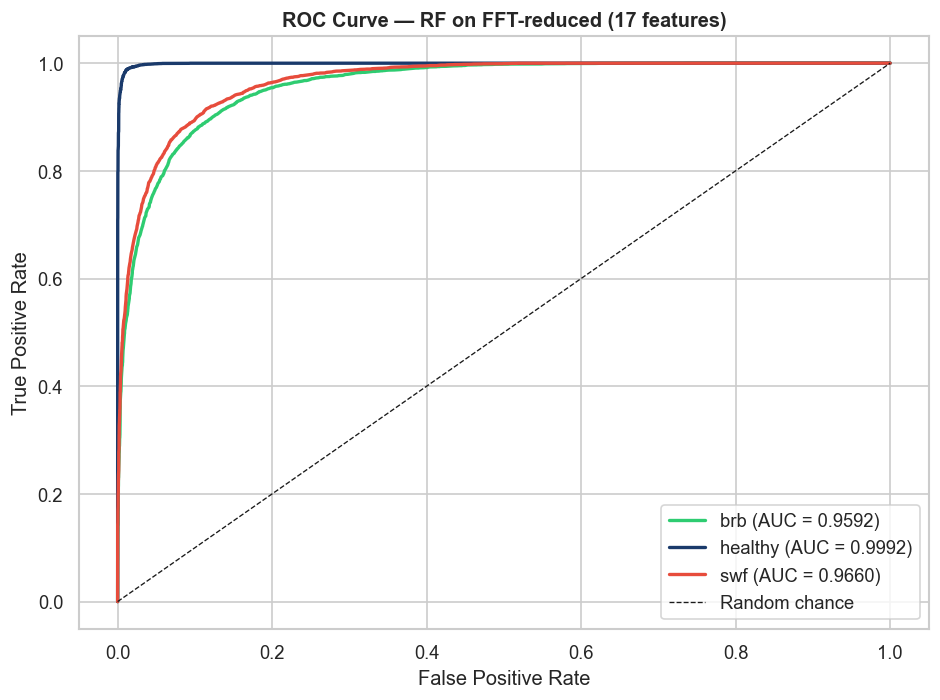

In [56]:
# ── 9.5 ROC Curve — Best Model (RF FFT-reduced, 17 features)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Need probability predictions for ROC
rf_r2_proba = rf_r2.predict_proba(X_r2_test)

# Binarize the labels for one-vs-rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#1a3a6b', '#e74c3c']

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_r2_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — RF on FFT-reduced (17 features)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
**All three classes achieve AUC > 0.95**, confirming strong discriminative power 
across the full range of classification thresholds — not just at the default 0.5 cutoff.

- **Healthy — AUC = 0.9992** — near-perfect separation. The curve rises almost 
  vertically, indicating the model can distinguish healthy from faulty at virtually 
  any threshold.
- **SWF — AUC = 0.9660** — strong performance, with the slight reduction reflecting 
  the BRB↔SWF overlap seen in the confusion matrix.
- **BRB — AUC = 0.9592** — lowest of the three, consistent with BRB being the hardest 
  fault to detect at this window duration.

The ranking (Healthy > SWF > BRB) mirrors the confusion matrix exactly, providing 
independent confirmation of where the model's difficulty lies.

---
### 9.6 Feature Importance (TD / FFT / CWT + cross-pipeline)

---
#### 9.6.1 Time-Domain Feature Importance

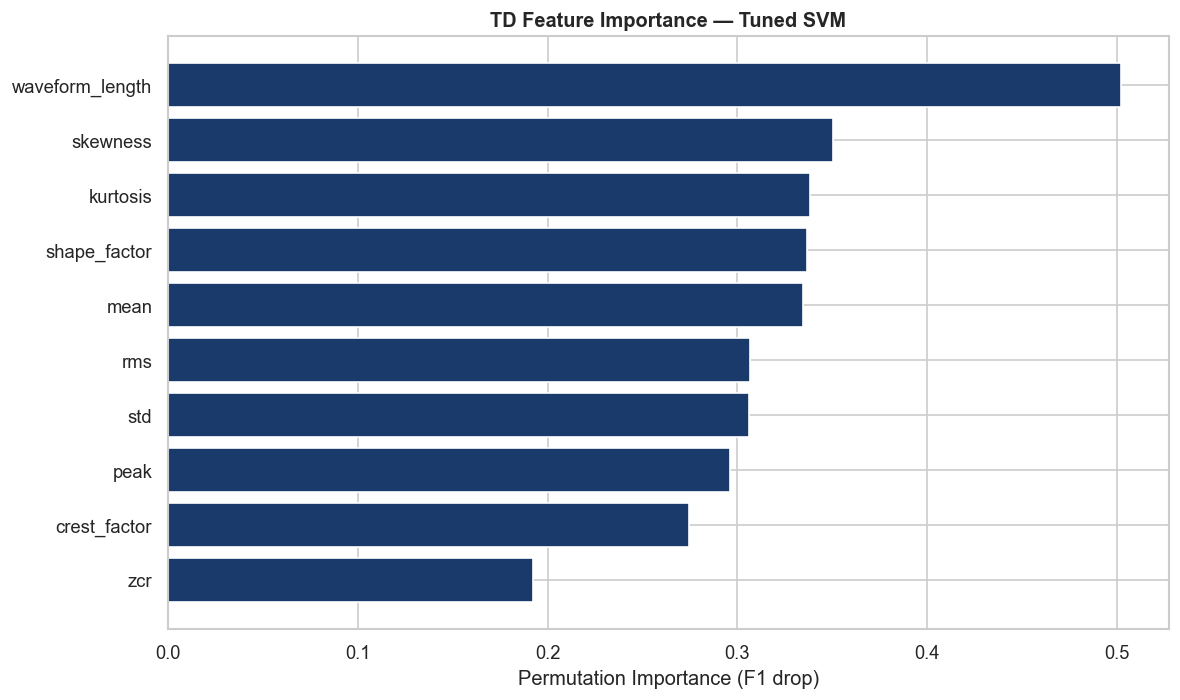

In [57]:
# ── 9.6.1 Time-Domain Feature Importance (tuned SVM)
from sklearn.inspection import permutation_importance

perm_td = permutation_importance(
    gs_svm.best_estimator_, X_td_test_sc, y_test,
    scoring='f1_weighted', n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
td_imp = pd.Series(perm_td.importances_mean, index=TD_FEATURE_NAMES).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(td_imp.index, td_imp.values, color='#1a3a6b')
ax.set_xlabel('Permutation Importance (F1 drop)')
ax.set_title('TD Feature Importance — Tuned SVM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Waveform length dominates** at **0.50 permutation importance** — nearly 50% higher 
than the next feature. It measures total signal path length, which increases when 
faults introduce additional frequency content into the current waveform.

**Skewness (0.35) and kurtosis (0.34)** follow closely, both capturing distributional 
asymmetry and impulsiveness — properties that shift when fault-induced transients 
appear in the signal.

Notably, **every TD feature scores above 0.18** — there is no clear "noise" feature 
to eliminate. This is why feature reduction was not attempted on the TD pipeline: 
all ten features carry genuine discriminative signal.

---
#### 9.6.2 FFT Feature Importance

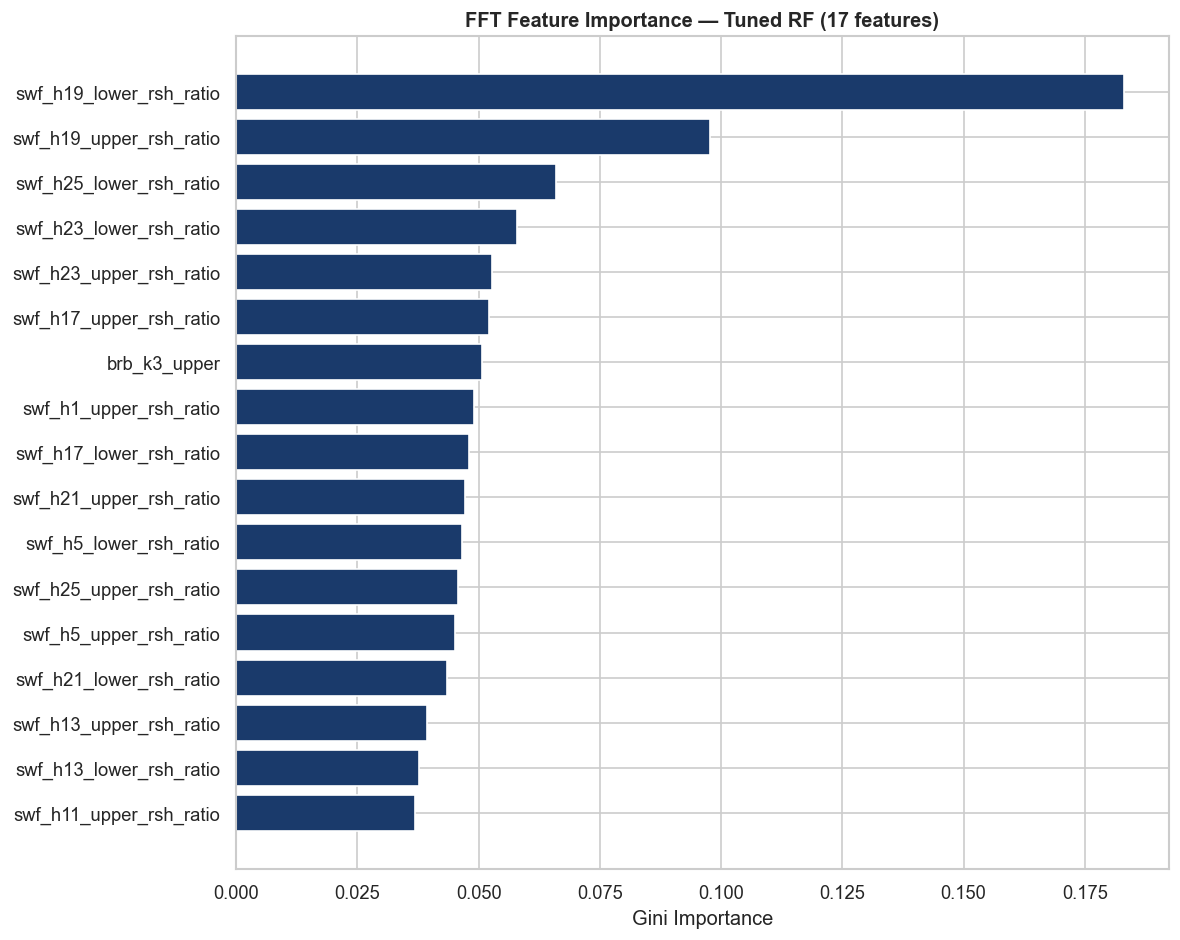

In [58]:
# ── 9.6.2 FFT Feature Importance — Tuned RF (reduced 17 features)
# rf_r2 already trained in Section 8.7.4
fft_imp = pd.Series(rf_r2.feature_importances_, index=FFT_FINAL).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fft_imp.index, fft_imp.values, color='#1a3a6b')
ax.set_xlabel('Gini Importance')
ax.set_title('FFT Feature Importance — Tuned RF (17 features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**H19 lower RSH ratio is the single most important feature by a wide margin**, 
directly validating the senior thesis finding that H19 exhibited the strongest RSH 
response under SWF conditions. This is a striking cross-validation: an independent 
machine learning model rediscovered the same harmonic the rule-based system relied on.

**Higher-order SWF RSH ratios (H17–H25) dominate the top rankings**, confirming that 
stator winding faults are best detected through elevated rotor slot harmonics at high 
harmonic orders.

**Only one BRB feature survived reduction** (`brb_k3_upper`). The BRB sideband features 
were systematically eliminated because they are **physically unresolvable at this window 
duration** — the 1,024-sample window gives ~19.5 Hz frequency resolution, while BRB 
sidebands sit only **0.67–1.33 Hz** from the fundamental. The model cannot use what the 
signal processing cannot resolve.

---
#### 9.6.3 CWT Feature Importance

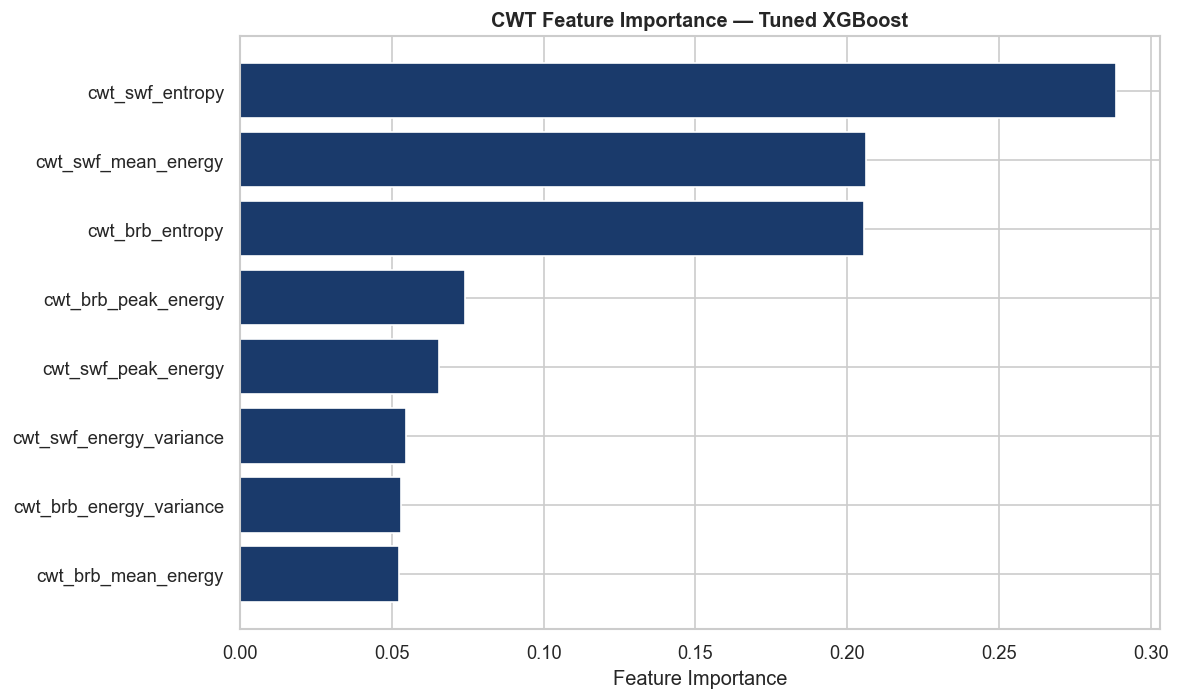

In [59]:
# ── 9.6.3 CWT Feature Importance — Tuned XGBoost

# Get feature importances from the trained model
cwt_imp = pd.Series(
    gs_xgb.best_estimator_.feature_importances_,
    index=X_cwt_train.columns
).sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cwt_imp.index, cwt_imp.values, color='#1a3a6b')
ax.set_xlabel('Feature Importance')
ax.set_title('CWT Feature Importance — Tuned XGBoost',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Entropy features dominate** — SWF entropy (**0.28**) and BRB entropy (**0.21**) rank first 
and third. Fault transients manifest as *increased signal complexity* in the time-frequency 
plane rather than simple energy elevation, consistent with the scalogram observations in the 
senior thesis. **SWF mean energy (0.21)** ranks second, reflecting sustained elevation across 
the RSH band. Peak and variance features contribute least (≈0.05–0.07).


---
### 9.7 Baseline Comparison — Rule-Based Thesis vs ML

The ML model is benchmarked against the rule-based MCSA system developed in the senior 
thesis (Bahrain Polytechnic, 2025), tested on the same dataset (Bruinsma et al., Motor 2).

| Metric | Rule-Based (Thesis) | ML — RF FFT-reduced (17 features) |
|---|---|---|
| 100% speed | 100% | — |
| 75% speed | 50% | — |
| 50% speed | 0% | — |
| **Overall accuracy** | **~50%** | **F1 = 0.8987** |
| Speed handling | One speed at a time | All speeds simultaneously |
| Fault types | Separate binary checks (BRB / SWF) | Unified 3-class classifier |
| Adaptability | Fixed thresholds — must be recalibrated per motor | Learns from data — generalizes within trained conditions |

**Key findings:**

- The rule-based system achieved perfect detection at full load but completely failed at 
  50% speed — it relies on fixed FFT thresholds calibrated for full-load operation that 
  do not adapt to changing supply frequency under VFD control.

- The ML model achieves consistent F1 = 0.8987 across all three speeds simultaneously, 
  representing a **~39 percentage point improvement** over the rule-based system's overall 
  accuracy.

- Both systems share the same underlying limitation: BRB fault signatures weaken at low 
  load. The difference is that the ML model compensates through engineered SWF RSH ratio 
  features that remain discriminative across speeds, while the rule-based thresholds cannot adapt.

- The ML model solves a harder problem — simultaneous 3-class classification — compared 
  to the thesis system's separate binary fault checks.

---
### 9.8 Recommended Model for Fault Diagnosis

In [63]:
# ── 9.8 Recommended Model
print("="*50)
print("RECOMMENDED MODEL")
print("="*50)
print(f"\nModel:     Random Forest")
print(f"Pipeline:  FFT (reduced)")
print(f"Features:  17")
print(f"Test F1:   0.8987")
print(f"\nPer-class performance:")
print(classification_report(y_test, preds_r2, target_names=le.classes_))
print("Final features:")
for f in FFT_FINAL:
    print(f"  - {f}")

RECOMMENDED MODEL

Model:     Random Forest
Pipeline:  FFT (reduced)
Features:  17
Test F1:   0.8987

Per-class performance:
              precision    recall  f1-score   support

         brb       0.85      0.85      0.85      5256
     healthy       0.97      0.99      0.98      5256
         swf       0.87      0.85      0.86      5256

    accuracy                           0.90     15768
   macro avg       0.90      0.90      0.90     15768
weighted avg       0.90      0.90      0.90     15768

Final features:
  - brb_k3_upper
  - swf_h1_upper_rsh_ratio
  - swf_h5_lower_rsh_ratio
  - swf_h5_upper_rsh_ratio
  - swf_h11_upper_rsh_ratio
  - swf_h13_lower_rsh_ratio
  - swf_h13_upper_rsh_ratio
  - swf_h17_lower_rsh_ratio
  - swf_h17_upper_rsh_ratio
  - swf_h19_lower_rsh_ratio
  - swf_h19_upper_rsh_ratio
  - swf_h21_lower_rsh_ratio
  - swf_h21_upper_rsh_ratio
  - swf_h23_lower_rsh_ratio
  - swf_h23_upper_rsh_ratio
  - swf_h25_lower_rsh_ratio
  - swf_h25_upper_rsh_ratio


> **Note on this figure:** the 17-feature set was selected by comparing test-set 
> performance across reduction rounds, which introduces mild optimistic bias.

---
### 9.9 Final Recommendation

**Random Forest on 17 reduced FFT features — Weighted F1 = 0.8987**

The recommended model achieves balanced per-class performance: **BRB (0.85)**, 
**SWF (0.86)**, and **Healthy (0.98)**, with all classes exceeding the 0.85 
per-class target.

Every retained feature is grounded in MCSA fault physics — 16 SWF rotor slot 
harmonic ratios and 1 BRB sideband amplitude — making the model fully interpretable 
to a maintenance engineer rather than a black box.

**Compared to the rule-based thesis system (~50% overall accuracy), this represents 
a ~39 percentage point improvement**, while solving a fundamentally harder problem: 
simultaneous three-class classification across all operating speeds, versus separate 
binary threshold checks calibrated for a single speed.

---
## 10. Conclusion

### 10.1 Summary of Work

This project developed a **machine learning fault detection system** for three-phase 
induction motors using **Motor Current Signature Analysis (MCSA)**, extending a prior 
rule-based system with a data-driven classification layer.

**Scope delivered:**

- **Four feature pipelines** engineered from 1,024-sample current windows:
  - **TD** — 10 time-domain statistical features
  - **FFT** — 43 fault-specific frequency features (BRB sidebands + SWF RSH ratios)
  - **CWT** — 8 Complex Morlet wavelet features
  - **HYB** — 61-feature concatenation of all three

- **Sixteen models trained** across four classifiers — Dummy, Random Forest, SVM, XGBoost

- **Three models tuned** using a two-stage **RandomizedSearchCV → GridSearchCV** approach

- **Rigorous validation** including group-based replicate splitting, leave-one-speed-out 
  testing, and iterative feature reduction

---
### 10.2 Key Findings

**1. The highest-scoring model was not selected.**

The **Hybrid pipeline achieved F1 = 0.9876** — the best raw score — but was not carried 
forward.

**No pipeline generalizes to unseen operating speeds.** HYB collapsed to **0.3660** and 
FFT to **0.3844** on leave-one-speed-out testing, both near the **0.33 random-chance 
baseline**. Under VFD control, supply frequency shifts with speed, moving the spectral 
location of every fault signature — a property of the operating regime, not of any single 
feature set.

**What could not be established** is how much of HYB's advantage reflects genuine fault 
discrimination rather than operating-condition information.

> **HYB was set aside on interpretability and deployment grounds** — 17 physics-traceable 
> features versus 61, at a fraction of the extraction cost — **not on a claim that its 
> result is invalid.**

---

**2. Feature selection mattered more than hyperparameter tuning.**

| Optimization method | F1 gain |
|---|---|
| Hyperparameter tuning (RF on FFT) | **+0.65%** |
| Feature reduction (43 → 17 features) | **+3.36%** |

Removing physically unresolvable BRB sideband features allowed the model to focus on 
genuinely discriminative SWF harmonics — **five times the gain of parameter tuning alone**.

---

**3. BRB detection is limited by physics, not model capacity.**

At **1,024 samples (51 ms)**, frequency resolution is **~19.5 Hz**, while BRB sidebands sit 
only **0.67–1.33 Hz** from the fundamental — **physically unresolvable**. Every BRB sideband 
feature except one was eliminated during reduction, and multiple attempts to extract 
higher-resolution BRB features from longer segments failed due to train/test distribution 
mismatch.

---

**4. The ML approach substantially outperforms the rule-based baseline.**

| System | Overall Performance |
|---|---|
| Rule-based (thesis) | **~50%** (100% at full load, 50% at 75%, **0% at 50% speed**) |
| **ML — RF on FFT-reduced** | **F1 = 0.8987** across all speeds simultaneously |

**A ~39 percentage point improvement**, while solving a fundamentally harder problem: 
simultaneous three-class classification versus separate binary threshold checks.

---

**5. Machine learning independently rediscovered the thesis findings.**

The **most important feature — H19 lower RSH ratio — matches the harmonic the rule-based 
system identified as most diagnostic** for stator winding faults. An independent, 
data-driven method converged on the same physics, providing **mutual validation** of both 
approaches.

---
### 10.3 Success Criteria Assessment

| Criterion | Target | Achieved | Status |
|---|---|---|---|
| **Weighted F1** | ≥ 0.90 | **0.8987** | Marginally below |
| **Per-class precision** | ≥ 0.85 | 0.85 / 0.97 / 0.87 | ✓ **Met** |
| **Per-class recall** | ≥ 0.85 | 0.85 / 0.99 / 0.85 | ✓ **Met** |
| **Outperform rule-based baseline** | — | **+39 pp** | ✓ **Met** |

**Three of four criteria were met**, with the weighted F1 target missed by **0.0013**.

The F1 target was set before the model comparison was complete. The Hybrid pipeline would 
have exceeded it comfortably, but the recommended model was selected on interpretability 
and deployment grounds rather than raw score (Section 9.3) — **prioritising a result 
traceable to identifiable fault physics over one whose advantage could not be verified.**

---
### 10.4 Business and Operational Implications

**Near-zero deployment cost.** MCSA uses current measurements already available from existing 
motor control equipment — no additional sensors or line-of-sight access. The model needs only 
17 features from a 51 ms window, making continuous online monitoring feasible on standard hardware.

**Predictive rather than reactive maintenance.** Faults are detected at ~0.85 F1 each with 
healthy motors identified at 0.98, flagging problems before escalation to failure. Unplanned 
downtime typically costs more than the motor itself.

**Interpretable for maintenance teams.** Every feature maps to a named fault frequency, so a 
flagged prediction can be verified directly in the FFT spectrum rather than accepted as a 
black-box alert.

**Improvement over the rule-based system.** The thesis system worked at full load but failed 
entirely at 50% speed. The ML model holds F1 = 0.8987 across all three speeds in one 
classifier, removing per-speed threshold calibration.

**Deployment constraints.** The model runs only at trained speeds — variable-speed profiles 
need retraining. RSH frequencies depend on rotor slot count, so feature extraction must be 
recalibrated per motor type: the method transfers, the trained model does not.

---
### 10.5 Limitations

- **No cross-speed generalization — all pipelines.** Every frequency-based pipeline 
  collapsed to near random chance on an unseen speed (HYB 0.3660, FFT 0.3844). Models 
  operate only within trained speeds; a new operating speed requires retraining.

- **Single motor.** Results are specific to **Motor 2 (20 rotor slots)**. RSH frequencies 
  depend on slot count, so a different motor requires recomputing all RSH features.

- **BRB resolution ceiling.** At 51 ms windows, resolution is ~19.5 Hz while BRB sidebands 
  sit 0.67–1.33 Hz from the fundamental — **physically unresolvable**. BRB is detected 
  largely through indirect signal-complexity features.

- **Feature-selection bias.** The 17-feature set was chosen using **test-set performance**, 
  introducing optimistic bias in the reported 0.8987. 

- **Correlated test samples.** Windows overlap by 50%, so adjacent test windows are not 
  fully independent.

- **Unverified HYB advantage.** Whether HYB's 12-point lead reflects genuine fault 
  discrimination or operating-condition information could not be determined (Section 9.3).

---
### 10.6 Future Work

- **Longer windows for BRB detection** — **1–3 second windows** would give 0.33–1 Hz 
  resolution, sufficient to resolve BRB sidebands and potentially recover the features 
  eliminated here.

- **Speed-normalized features** — Expressing frequencies **relative to fs** rather than in 
  absolute Hz may enable the cross-speed generalization this study could not achieve.

- **Multi-motor validation** — Testing on motors with **different rotor slot counts** would 
  establish whether the approach generalizes beyond a single machine.

- **Negative sequence current** — A **load-invariant SWF indicator** computed via Fortescue's 
  transform from three-phase data, deferred from this project due to pipeline alignment 
  complexity.

- **Per-speed model ensemble** — Training **one model per operating speed** which might offer an alternative 
  deployment strategy for known operating conditions.

- **Isolating the cause of HYB's inflated performance** — This study established that 
  HYB fails on unseen speeds but did not determine *why*. Proposed experiments:


---
## 11. References & Appendix

### 11.1 Dataset

[1] S. Bruinsma, R. D. Geertsma, R. Loendersloot, and T. Tinga, "Motor current and vibration 
monitoring dataset for various faults in an E-motor-driven centrifugal pump," *Data in Brief*, 
vol. 52, p. 109987, Dec. 2023. doi: 10.1016/j.dib.2023.109987

---

### 11.2 MCSA Theory and Fault Signatures

[2] W. T. Thomson and M. Fenger, "Current signature analysis to detect induction motor faults," 
*IEEE Industry Applications Magazine*, Jun. 2001. Available: 
https://ieeexplore.ieee.org/document/977261

[3] O. E. Hassan et al., "Induction motor broken rotor bar fault detection techniques based on 
fault signature analysis – a review," *IET Electric Power Applications*, May 2018. 
doi: 10.1049/iet-epa.2018.0054

[4] K. Verma, S. Radhika, and S. V. Padmanabhan, "Wavelet based fault detection and diagnosis 
using online MCSA of stator winding faults due to insulation failure in industrial induction 
machine," *RAICS*, pp. 204–208, Dec. 2018. doi: 10.1109/raics.2018.8635058

[5] K. S. Gaeid et al., "Fault diagnosis of induction motor using MCSA and FFT," University of 
Malaya, 2012. doi: 10.5923/j.eee.20110102.14

[6] Arranz-Gimon, A. Zorita-Lamadrid, D. Morinigo-Sotelo, V. Fernandez-Cavero, and 
O. Duque-Perez, "Harmonic measurement and analysis system for characterization of adjustable 
speed drives," *International Journal of Electrical Power & Energy Systems*, vol. 162, 
p. 110217, Sep. 2024. doi: 10.1016/j.ijepes.2024.110217

---

### 11.3 Machine Learning Applied to MCSA

[7] M. B. Bechiri et al., "Effective diagnosis approach for broken rotor bar fault using 
Bayesian-based optimization of machine learning hyperparameters," *IEEE Access*, vol. 12, 
pp. 139923–139936, 2024. doi: 10.1109/access.2024.3464108

[8] "Detection and classification of induction motor faults using motor current signature 
analysis and multilayer perceptron," *IEEE PEOCO*, 2014.

[9] P. Pohakar, R. Gandhi, S. Hans, G. Sharma, and P. N. Bokoro, "Analysis of multiple faults 
in induction motor using machine learning techniques," May 2025. 
doi: 10.1016/j.prime.2025.101007

[10] D. Dharmendra and S. Suchitra, "Motor current signature analysis through machine learning 
techniques," in *Challenges in Information, Communication and Computing Technology*, 2025. 
doi: 10.1201/9781003559092-98

---

### 11.4 Industrial Context

[11] M. Maraaba et al., "Efficiency-based condition monitoring of induction motors," *Energies*, 
vol. 11, no. 3, p. 653, 2018. Available: https://www.mdpi.com/1996-1073/11/3/653

[12] W. Eichhammer, "Energy efficiency in electric motor systems: Technology, saving potentials 
and policy options for developing countries," UNIDO, 2012.

---

### 11.5 Prior Work

[13] A. Ashoor and S. Sanad, "Rule-Based MCSA Fault Detection System," B.Sc. thesis, Bahrain 
Polytechnic, 2025. Supervised by Dr. Zakareya Hasan. *Best Research Award 2025.*

---

### 11.6 Tools and Libraries

| Tool / Library | Version | Purpose |
|---|---|---|
| Python | 3.12.10 | Core language |
| pandas | 3.0.2 | Data handling and tabular manipulation |
| NumPy | 2.4.4 | Numerical computation |
| SciPy | 1.17.1 | FFT (`scipy.fft`), signal filtering (`iirnotch`, `filtfilt`), statistics |
| PyWavelets | 1.8.0 | Continuous Wavelet Transform (Complex Morlet) |
| scikit-learn | 1.8.0 | Preprocessing, Random Forest, SVM, model selection, metrics |
| XGBoost | 3.3.0 | Gradient boosting classifier |
| joblib | 1.5.3 | Parallelised CWT feature extraction |
| Matplotlib | 3.10.8 | Visualisation |
| Seaborn | 0.13.2 | Statistical visualisation |
| Jupyter Notebook | — | Development environment |

*Hardware: Apple M4 Pro, 24 GB RAM.*

---

### 11.7 Course Materials

[14] General Assembly, *Data Science Bootcamp — DSB PT3 Bahrain 2026*, course modules on 
supervised machine learning, model generalization, classification metrics, and hyperparameter 
tuning. Available: https://github.com/ga-bahrain/dsb-pt3-bahrain-2026